**References:**

- https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py
- https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

- https://github.com/pytorch/tutorials/blob/main/intermediate_source/reinforcement_q_learning.py

- https://github.com/keras-team/keras-io/blob/master/examples/rl/ppo_cartpole.py

- Zhao, D., Wang, H., Shao, K., & Zhu, Y. (2016, December). Deep reinforcement learning with experience replay based on SARSA. In 2016 IEEE symposium series on computational intelligence (SSCI) (pp. 1-6). IEEE. DOI: http://dx.doi.org/10.1109/SSCI.2016.7849837

- Cao, L., ZHANG, Y. L., & LAI, J. (2018). Deep reinforcement learning with sarsa and Q-learning: A hybrid approach. IEICE TRANSACTIONS on Information and Systems, 101(9), 2315-2322. DOI: https://doi.org/10.1587/transinf.2017EDP7278

- Bantel, L., Domanski, P., & Pflüger, D. (2024, June). High-Fidelity Simulation of a Cartpole for Sim-to-Real Deep Reinforcement Learning. In 2024 4th Interdisciplinary Conference on Electrics and Computer (INTCEC) (pp. 1-6). IEEE. DOI: https://doi.org/10.1109/INTCEC61833.2024.10602859.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle

In [ ]:
import warnings

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import gym
import scipy.signal
from gym import spaces, logger

In [ ]:
np.seterr(all="ignore")

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [ ]:
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [ ]:
warnings.filterwarnings("ignore", message=".*Conversion of an array with ndim > 0 to a scalar.*")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [ ]:
print(device)

cpu


In [ ]:
from numpy.linalg import matrix_power
from scipy.linalg import block_diag

## Functions and class

In [ ]:
class CartPoleEnvCustomized(gym.Env):
    """
    ### Description
    This environment corresponds to the version of the cart-pole problem
    described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    A pole is attached by an un-actuated joint to a cart, which moves along a
    frictionless track. The pendulum starts upright, and the goal is to prevent
    it from falling over by increasing and reducing the cart's velocity.
    ### Action Space
    The agent take a 1-element vector for actions.
    The action space is `(action)` in `[0, 1]`, where `action` is used to push
    the cart with a fixed amount of force:
    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push cart to the left  |
    | 1   | Push cart to the right |
    Note: The amount the velocity is reduced or increased is not fixed as it depends on the angle the pole is pointing.
    This is because the center of gravity of the pole increases the amount of energy needed to move the cart underneath it
    ### Observation Space
    The observation is a `ndarray` with shape `(4,)` where the elements correspond to the following:
    | Num | Observation           | Min                  | Max                |
    |-----|-----------------------|----------------------|--------------------|
    | 0   | Cart Position         | -4.8*                 | 4.8*                |
    | 1   | Cart Velocity         | -Inf                 | Inf                |
    | 2   | Pole Angle            | ~ -0.418 rad (-24°)** | ~ 0.418 rad (24°)** |
    | 3   | Pole Angular Velocity | -Inf                 | Inf                |
    **Note:** above denotes the ranges of possible observations for each element, but in two cases this range exceeds the
    range of possible values in an un-terminated episode:
    - `*`: the cart x-position can be observed between `(-4.8, 4.8)`, but an episode terminates if the cart leaves the
    `(-2.4, 2.4)` range.
    - `**`: Similarly, the pole angle can be observed between  `(-.418, .418)` radians or precisely **±24°**, but an episode is
    terminated if the pole angle is outside the `(-.2095, .2095)` range or precisely **±12°**
    ### Rewards
    Reward is 1 for every step taken, including the termination step. The threshold is 475 for v1.
    ### Starting State
    All observations are assigned a uniform random value between (-0.05, 0.05)
    ### Episode Termination
    The episode terminates of one of the following occurs:
    1. Pole Angle is more than ±12°
    2. Cart Position is more than ±2.4 (center of the cart reaches the edge of the display)
    3. Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    """

    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 50}

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.dt = 0.02  # seconds between state updates
        self.kinematics_integrator = None # "euler","semi-implicit euler"


        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.viewer = None
        self.state = None

        self.steps_beyond_done = None

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        self.NumIntegrationsSteps = 1
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        dt_prime = self.dt/self.NumIntegrationsSteps
        self.tau = dt_prime
        self.MPC.dt = dt_prime
        self.MPC.plant.tau1 = dt_prime
        self.MPC.ref_model.tau1 = dt_prime
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0

        self.ideal_env = False
        ####


    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg

        x, x_dot, theta, theta_dot = self.state
        force = +self.force_mag if action == 1 else -self.force_mag #+/-10N
        #wanted_torque_ret = self.wanted_torque #return old action
        torque_wanted = force*self.DCMotor_radius
        self.MPC.y_spf = torque_wanted
        beta_AF = 0.135#0.5
        torque_wanted =  (beta_AF)*self.wanted_torque+(1-beta_AF)*torque_wanted
        self.wanted_torque = torque_wanted
        self.MPC.y[0] = torque_wanted #self.MPC.y_spf #torque_wanted
        wanted_torque_ret = self.wanted_torque

        ### Customization changes #####
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
            if self.ideal_env:
              torque_actual = torque_wanted
            else:
              self.MPC.plant.thetadot =  x_dot/self.DCMotor_radius
              torque_actual = self.MPC.step()
            F = torque_actual/self.DCMotor_radius
            #F = force #ideal env
            ###

            costheta = math.cos(theta)
            sintheta = math.sin(theta)

            # For the interested reader:
            # https://coneural.org/florian/papers/05_cart_pole.pdf
            temp = (
                F + self.polemass_length * theta_dot ** 2 * sintheta
            ) / self.total_mass
            thetaacc = (self.gravity * sintheta - costheta * temp) / (
                self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
            )
            xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

            if self.kinematics_integrator == "euler":
                x = x + self.tau * x_dot
                x_dot = x_dot + self.tau * xacc
                theta = theta + self.tau * theta_dot
                theta_dot = theta_dot + self.tau * thetaacc
            elif self.kinematics_integrator == "semi-implicit euler":
                x_dot = x_dot + self.tau * xacc
                x = x + self.tau * x_dot
                theta_dot = theta_dot + self.tau * thetaacc
                theta = theta + self.tau * theta_dot
            else: # trapz on velocities
                new_x_dot = x_dot + self.tau * xacc
                new_theta_dot = theta_dot + self.tau * thetaacc
                x = x + self.tau * (x_dot+new_x_dot)/2
                theta = theta + self.tau * (theta_dot+new_theta_dot)/2
                x_dot = new_x_dot+0
                theta_dot = new_theta_dot+0

        self.state = (x, x_dot, theta, theta_dot)

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
        )

        if not done: # if we inside the valid range
            reward = 1.0

        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0

        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.state, dtype=np.float32), reward, done, {} ,wanted_torque_ret, torque_actual


    def reset(self, return_info = False, options = None):
        #super().reset(seed=seed)
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_done = None

        ### reset MPC
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0
        #

        if not return_info:
            return np.array(self.state, dtype=np.float32)
        else:
            return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        screen_width = 600
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        carty = 100  # TOP OF CART
        polewidth = 10.0
        polelen = scale * (2 * self.length)
        cartwidth = 50.0
        cartheight = 30.0

        if self.viewer is None:
            #from gym.utils import pyglet_rendering
            from gym.envs.classic_control import rendering as pyglet_rendering

            self.viewer = pyglet_rendering.Viewer(screen_width, screen_height)
            l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
            axleoffset = cartheight / 4.0
            cart = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            self.carttrans = pyglet_rendering.Transform()
            cart.add_attr(self.carttrans)
            self.viewer.add_geom(cart)
            l, r, t, b = (
                -polewidth / 2,
                polewidth / 2,
                polelen - polewidth / 2,
                -polewidth / 2,
            )
            pole = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            pole.set_color(0.8, 0.6, 0.4)
            self.poletrans = pyglet_rendering.Transform(translation=(0, axleoffset))
            pole.add_attr(self.poletrans)
            pole.add_attr(self.carttrans)
            self.viewer.add_geom(pole)
            self.axle = pyglet_rendering.make_circle(polewidth / 2)
            self.axle.add_attr(self.poletrans)
            self.axle.add_attr(self.carttrans)
            self.axle.set_color(0.5, 0.5, 0.8)
            self.viewer.add_geom(self.axle)
            self.track = pyglet_rendering.Line((0, carty), (screen_width, carty))
            self.track.set_color(0, 0, 0)
            self.viewer.add_geom(self.track)

            self._pole_geom = pole

        if self.state is None:
            return None

        # Edit the pole polygon vertex
        pole = self._pole_geom
        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )
        pole.v = [(l, b), (l, t), (r, t), (r, b)]

        x = self.state
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        self.carttrans.set_translation(cartx, carty)
        self.poletrans.set_rotation(-x[2])

        return self.viewer.render(return_rgb_array=mode == "rgb_array")

    def close(self):
        if self.viewer:
            self.viewer.close()
            self.viewer = None

In [ ]:
# High Fidelity Cartpole ENV by L. Bantel, et al (https://doi.org/10.1109/INTCEC61833.2024.10602859)
# https://github.com/SC-SGS/High-Fidelity-Cartpole
import math
from math import pi, cos, sin, trunc, e
from typing import Optional, Union
import gin

import numpy as np
import pygame
from pygame import gfxdraw

import gym
from gym import spaces, logger
from gym.utils import seeding

#@gin.configurable
class HighFidelityCartPoleEnvCustomized(gym.Env[np.ndarray, Union[int, np.ndarray]]):

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self,
                 force_steps = [0,2,5,7,10,15,20],#[0,5,10,15,20],# [0,100,150,200,250]
                 masscart = 0.94,
                 masspole = 0.1,
                 length = 0.1778,
                 force_mag = 3.0,
                 NumIntegrationsSteps = 1, #internal_tau = 0.02,
                 dt=0.02,#tau = 0.02,
                 x_threshold = 0.3,
                 pole_resistance = 0.99,
                 cart_resistance = 0.99,
                 force_curve = [0,1,0],
                 evaluation = False,#False,
                 swingup = False,#False,
                 discrete_state = False,
                 action_in_state = False): #action_in_state=True

        #set "evaluation" in the code to obtain a second environment for evaluation,
        #for conistent resets

        #physical parameters
        self.force_steps = force_steps
        self.gravity = 9.8
        self.masscart = masscart
        self.masspole = masspole
        self.total_mass = self.masspole + self.masscart
        self.length = length  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag_mean = force_mag
        self.force_mag = None
        self.dt = dt
        self.NumIntegrationsSteps = NumIntegrationsSteps
        self.internal_tau = dt/NumIntegrationsSteps #internal_tau # seconds for euler step
        #self.tau = tau  # seconds between state updates, multiple of internal tau
        self.mean_pole_resistance = e**(pole_resistance*self.internal_tau)
        self.mean_cart_resistance = cart_resistance
        self.cart_resistance = None
        self.pole_resistance = None
        self.force_curve = force_curve

        #different experimental setups
        self.evaluation = evaluation
        self.swingup = swingup
        self.action_in_state = action_in_state
        self.discrete_state = discrete_state

        self.states = []


        # Angle at which to fail the classical task
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = x_threshold

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                pi,
                np.finfo(np.float32).max
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(len(self.force_steps) * 2 - 1)


        #action within state
        if self.action_in_state:
            action = np.ones(len(force_steps)*2+1)
            self.observation_space = spaces.Box(np.concatenate((-high, action*0)), np.concatenate((high, action)), dtype=np.float32)
            print('action_in_state = True')
        else:
            self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None
        self.num_steps = None

        self.steps_beyond_done = None

        self.last_action = None
        self.last_reward = 0

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        #dt_prime = self.dt/self.NumIntegrationsSteps
        #self.tau = dt_prime
        self.MPC.dt = self.internal_tau
        self.MPC.plant.tau1 = self.internal_tau
        self.MPC.ref_model.tau1 = self.internal_tau
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0
        self.kinematics_integrator = None # "euler","semi-implicit euler"


        self.ideal_env = False
        ####



    def update_state(self, state, force, tau):
        #function implements the actual differential equation and integration

        x, x_dot, theta, theta_dot = state

        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf

        #sign function can lead to weird results depending on the time-step-width
        #possible replacement is a scaled and parameterized sigmoid

        temp = (
            force + self.polemass_length * theta_dot ** 2 * sintheta
            - self.cart_resistance*np.tanh(x_dot*tau)#sign(x_dot)
        ) / self.total_mass

        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
        )

        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass


        if self.kinematics_integrator == "euler":
          x = x + self.tau * x_dot
          x_dot = x_dot + tau * xacc
          theta = theta + tau * theta_dot
          theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
        elif self.kinematics_integrator == "semi-implicit euler":
          x_dot = x_dot + tau * xacc
          x = x + self.tau * x_dot
          theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
          theta = theta + tau * theta_dot
        else: # trapz on velocities
          new_x_dot = x_dot + tau * xacc
          new_theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
          x = x + tau * (x_dot+new_x_dot)/2
          theta = theta + tau * (theta_dot+new_theta_dot)/2
          x_dot = new_x_dot+0
          theta_dot = new_theta_dot+0

        theta = angle_normalize(theta)


        return (x, x_dot, theta, theta_dot)



    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg
        assert self.state is not None, "Call reset before using step method."


        action = action - len(self.force_steps) + 1



        if action > 0:
            dir = 1
        elif action < 0:
            dir = -1
        else:
            dir = 0


        #motor values to use (0-255)
        force = self.force_steps[abs(action)]


        #force curve of the cartpole
        force = self.force_curve[0]*force**2 - self.force_curve[1]*force +  self.force_curve[2]
        force *= dir
        torque_wanted=force*self.DCMotor_radius
        #wanted_torque_ret = self.wanted_torque #return old action
        self.MPC.y_spf = torque_wanted
        beta_AF = 0.5#0.5,0.135
        torque_wanted =  (beta_AF)*self.wanted_torque+(1-beta_AF)*torque_wanted
        self.wanted_torque = torque_wanted
        self.MPC.y[0] = torque_wanted #self.MPC.y_spf #torque_wanted
        wanted_torque_ret = self.wanted_torque

        # get current state
        x, x_dot, theta, theta_dot = self.state

        if self.discrete_state:
            old_disc_theta = discretize_angle(theta)


        #internal finer stepping of the simulation
        for i in range(self.NumIntegrationsSteps):
          if self.ideal_env:
            torque_actual = torque_wanted
          else:
            self.MPC.plant.thetadot =  x_dot/self.DCMotor_radius
            torque_actual = self.MPC.step()
          F = torque_actual/self.DCMotor_radius
          self.state = self.update_state(self.state, F, self.internal_tau)
          x, x_dot, theta, theta_dot = self.state



        x, x_dot, theta, theta_dot = self.state

        #calculating the derivatives of the discrete state for the output
        if self.discrete_state:
            new_disc_theta = discretize_angle(theta)

            if new_disc_theta > pi/2 and old_disc_theta < -pi/2:
                old_disc_theta += 2*pi
            elif new_disc_theta < -pi/2 and old_disc_theta > pi/2:
                old_disc_theta -= pi

            disc_theta_dot = (new_disc_theta - old_disc_theta)/self.dt
            out_state = (x, x_dot, new_disc_theta, disc_theta_dot)
        else:
            out_state = self.state


        #variable to check, if pole is upright
        if abs(theta) < self.theta_threshold_radians:
            self.swingup_done = True
        elif abs(theta) > self.theta_threshold_radians:
            self.swingup_done = False


        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or abs(theta_dot) > 5*pi
            or (abs(theta) > self.theta_threshold_radians and not self.swingup)
        )

        if not done:
            if self.evaluation:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            else:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            #additional addon for training swingup faster

            if self.swingup and abs(theta) < 5/180*pi:
                reward += 5
                if abs(theta_dot) < 6/180*pi:
                    reward += 5


        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 0
        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0


        self.num_steps += 1
        self.last_action = action
        self.last_reward = reward

        #append action to state if neccessary
        if self.action_in_state:
            action_arr = np.zeros(len(self.force_steps)*2+1)
            action_arr[action+len(self.force_steps)] = 1
            return np.concatenate((np.array(out_state, dtype=np.float32), action_arr)), reward, done, {} ,torque_wanted, torque_actual
        else:
            return np.array(out_state, dtype=np.float32), reward, done, {} ,torque_wanted, torque_actual


    def reset(
        self,
        *,
        seed: Optional[int] = None,
        return_info: bool = False,
        options: Optional[dict] = None,
    ):
        super().reset(seed=seed)

        #reset with slight perturbation
        self.state = self.np_random.uniform(low=-0.1, high=0.1, size=(4,))
        #vertical
        self.state[2] = self.np_random.uniform(low = -2/180*pi, high = 2/180*pi)

        if self.swingup:

            #for evaluation purposes start always hanging
            #for training, start with an arbitary pole angle
            if self.evaluation:
                self.state = self.np_random.uniform(low=-0.01, high=0.01, size=(4,))
                self.state[2] = angle_normalize(pi - self.np_random.uniform(low=-0.01, high=0.01))
            else:
                self.state[2] = self.np_random.uniform(low=-pi, high=pi)


        #perturbate resistance parameters
        self.cart_resistance = self.mean_cart_resistance#np.random.uniform(low = self.mean_cart_resistance*0.95, high = self.mean_cart_resistance*1.05)
        self.pole_resistance = self.mean_pole_resistance#np.random.uniform(low = self.mean_pole_resistance*0.97, high = min(self.mean_pole_resistance*1.03,0.9999))



        #used to train for multiple poles on one agent
        """"
        pend = self.np_random.randint(2)d

        if pend == 0:

            self.masspole = 0.127
            self.total_mass = self.masspole + self.masscart
            self.length = 0.1778  # actually half the pole's length
            self.polemass_length = self.masspole * self.length

        else:

            self.masspole = 0.23
            self.total_mass = self.masspole + self.masscart
            self.length = 0.3302  # actually half the pole's length
            self.polemass_length = self.masspole * self.length
        """


        self.num_steps = 0
        self.steps_beyond_done = None
        self.last_action = 0
        self.swingup_done = False

        ### reset MPC
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0

        if self.action_in_state:
            action = np.zeros(len(self.force_steps)*2+1)
            out = np.concatenate((np.array(self.state, dtype=np.float32), action))
        else:
            out = np.array(self.state, dtype=np.float32)

        if not return_info:
            return out
        else:
            return out, {}




    def render(self, mode="human"):
        screen_width = 608
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        polewidth = 10.0
        polelen = scale * self.length
        cartwidth = 50.0
        cartheight = 30.0

        if self.state is None:
            return None

        x = self.state

        if self.screen is None:
            pygame.init()
            self.screen = pygame.display.set_mode((screen_width, screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))

        fontObj = pygame.font.Font(None, 32)
        cart_res = fontObj.render(str(self.cart_resistance), True, (0,0,0), None)

        l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
        axleoffset = cartheight / 4.0
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        carty = int(screen_height/2 + cartheight/2)  # TOP OF CART
        cart_coords = [(l, b), (l, t), (r, t), (r, b)]
        cart_coords = [(c[0] + cartx, c[1] + carty) for c in cart_coords]
        gfxdraw.aapolygon(self.surf, cart_coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, cart_coords, (0, 0, 0))

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)
        gfxdraw.aapolygon(self.surf, pole_coords, (202, 152, 101))
        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )

        gfxdraw.hline(self.surf, 0, screen_width, carty, (0, 0, 0))

        #draw force steps in render
        for i in range(-len(self.force_steps), len(self.force_steps)+1):
            color = (0,0,0)
            if i == self.last_action:
                color = (255,0,0)
            gfxdraw.filled_circle(
                    self.surf,
                    int(screen_width/2+i*20),
                    int(50),
                    5,
                    color,
            )

        #reward value
        gfxdraw.rectangle(self.surf, (20,20,20,80),(0,0,0))

        gfxdraw.box(self.surf, (20,20,20,self.last_reward*80),(0,0,0))


        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if mode == "human":
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        if mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )
        else:
            return self.isopen

    def close(self):
        if self.screen is not None:
            pygame.quit()
            self.isopen = False


def angle_normalize(x):
    return ((x + np.pi) % (2 * np.pi)) - np.pi



#not used, possible distribution for perturbating physical parameters
def trunc_normal(mean, sigma, lower = 0, upper = 1):
    i = 0
    x = mean

    while i < 50:
        x =  np.random.normal(mean, sigma)
        if x >= lower and x <= upper:
            break
        i += 1

    if i >= 50:
        x = mean

    return x


def discretize_angle(theta):
    disc = int((theta+pi)/pi*2048)-2048 #range from -2048 to 2048
    return disc/2048*pi #range from -pi to pi


def sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

def sigmoid(x,tau):
    return 2/(1 + np.exp(-x*tau))-1

In [ ]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
    self.ZOH_mode = True
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0
    self.F = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    if self.ZOH_mode:
      a = np.exp(-self.tau1*self.Resistor_R/self.inductor_L)
      self.current = a*self.current + (1-a)/self.Resistor_R*(u-voltage_BEMF)
    else:
      self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    self.F=f2 #f1 #f2 #(f1+f2)/2
    return self.F # return actual applied torque

  def reset(self):
    self.current = 0.0
    self.F = 0.0


In [ ]:
class ReferenceModel():

  def __init__(self):
    self.tau1 = 0.05
    self.A_rm = np.array([[0]])
    self.B_rm = np.array([[0]])
    self.y_rm = np.array([[0]])

  def step(self, u):
    # TODO: complete
    #for _ in range(0,1):
    y_m_prev = self.y_rm+0
    self.y_rm = self.A_rm@self.y_rm + self.B_rm*u
    return self.y_rm #y_m_prev #self.y_rm

  def reset(self):
    self.y_rm = np.array([[0]])




In [ ]:
class ModelPredictCtrl:

  def __init__(self,dt=0.01, N=60,
               a_sp = 1, b_sp = 0,
               R_resistor = 1, L_inductor = 0.1,
               k_t=1,k_w=1):
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.dt = dt
    self.a_sp = a_sp
    self.b_sp = b_sp
    self.R_resistor = R_resistor
    self.L_inductor = L_inductor
    self.k_t = k_t
    self.k_w = k_w
    self.N=N
    self.A_pm = None
    self.B_pm = None
    self.A = None
    self.B = None
    self.Atilde = None
    self.Q1 = np.array([[1,-1]]) ####
    self.Q = None
    self.R = None
    self.y_spf = None
    self.K = None
    self.K_MPC = None
    self.y = np.array([[0],[0]])
    self.u = 0


  def ConfigureMPCParams(self):

    # Configure reference model
    A_sp = self.a_sp
    A_rm = np.array([[A_sp]])
    B_rm = np.array([[self.b_sp]])
    self.ref_model.A_rm = A_rm
    self.ref_model.B_rm = B_rm


    # Configure plant model
    dt = self.dt
    # note: self.dt and self.ref_model.tau1 aren't necessarily the same
    A_sp = self.a_sp
    A_pm = np.exp(-self.R_resistor/self.L_inductor*dt)
    B_pm = self.k_t*(1-A_pm)/self.R_resistor
    B = np.array([[self.b_sp],[B_pm]])
    self.A = np.array([[A_sp,0],[0,A_pm]])
    self.B = B


    # Confgure weight matrices Q & R and control gain K_mpc
    N = self.N
    A = self.A
    B = self.B
    B_shape_1 = B.shape[1]

    Atilde = 0
    for n in range(0,N):
      if n==0:
        Atilde = A*1
      else:
        Atilde = np.vstack((Atilde,matrix_power(A, n+1)))
    self.Atilde = Atilde

    Btilde = 0
    for i in range(0,N):
      if i==0:
        Btilde = B*1
      else:
        Btilde = np.hstack((Btilde,B*0))
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = matrix_power(A, i)@B
        elif i>=j:
          row = np.hstack((row,matrix_power(A, i-j)@B))
        else:
          row = np.hstack((row,i*0*B))
      Btilde = np.vstack((Btilde,row))

    Q1 = self.Q1
    Q1_N = Q1+0
    for n in range(1,N):
      Q1_N = block_diag(Q1_N,Q1)
    W_Q = 100*np.eye(N)
    W_Q[0,0] = 500
    Q = ((Q1_N.T)@(W_Q))@Q1_N#####
    self.Q = Q

    I=np.eye(B_shape_1)
    O=0*I

    R1 = 0
    for i in range(0,N):
      if i==0:
        R1 = I
      else:
        R1 = np.hstack((R1,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j:
          Mij = I
        elif i==j+1:
          Mij = -I
        else:
          Mij = O
        row = np.hstack((row,Mij))
      R1 = np.vstack((R1,row))

    R2 = 0
    for i in range(0,N):
      if i==0:
          R2 = I
      else:
          R2 = np.hstack((R2,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I
          continue
        else:
          Mij = I*(i==j)
        row = np.hstack((row,Mij))
      R2 = np.vstack((R2,row))

    R3 = 0
    for i in range(0,N):
      if i==0:
        R3 = I
      else:
        R3 = np.hstack((R3,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j+1:
          Mij = -I
        else:
          Mij = (i<=j)*I/(N-i)
        row = np.hstack((row,Mij))
      R3 = np.vstack((R3,row))

    W_R = 0.01*np.eye(N*B_shape_1)
    W_R[0,0]=0.2 #5
    R=0.334*R1+0.333*R2+0.333*R3
    R=(R.T)@(W_R)@(R)
    self.R=R

    BTQ = Btilde.T@Q
    BTQB= BTQ@Btilde
    K = -np.linalg.pinv(BTQB+R)@BTQ
    R0 = 0
    for i in range(0,N):
      if i==0:
          R0 = I
      else:
          R0 = np.hstack((R0,O))
    self.K = R0@K
    self.K_MPC = self.K@Atilde
    #self.Atilde = Atilde

  def computeCtrlInput(self, y):#, w):
    self.u = (self.K_MPC@y).item()
    self.u = np.clip(self.u, -10, 10)
    return self.u

  def step(self):
    #self.y[0] = y_sp0
    u = self.computeCtrlInput(self.y)#, self.plant.thetadot)
    self.u = u#+1*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_rm = self.ref_model.step(self.u)#(u)
    self.u = u+self.k_w*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_pm = self.plant.step(self.u)
    self.y = np.vstack((y_rm,y_pm))
    return self.y[1].item()

  def reset(self):
    self.y = np.array([[0],[0]])
    self.u = 0




In [ ]:
CartPole = HighFidelityCartPoleEnvCustomized #HighFidelityCartPoleEnvCustomized #CartPoleEnvCustomized
env = CartPole()
observation = env.reset()
#train_mode = True
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

In [ ]:
print("Sample Time: dt= ", env.dt)
print("Num Integrations Steps: N= ", env.NumIntegrationsSteps)
print("Integration Time: dt/N=", env.dt/env.NumIntegrationsSteps)

Sample Time: dt=  0.02
Num Integrations Steps: N=  1
Integration Time: dt/N= 0.02


In [ ]:
K_MPC = env.MPC.K_MPC

In [ ]:
print("K_MPC= ", K_MPC)

K_MPC=  [[ 5.4295893  -4.44155325]]


##Replay Memory

In [ ]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward', 'next_action'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        #b=random.sample(population=list(self.memory)[:-1], k=batch_size-1)
        #b.append(self.memory[-1])
        b=random.sample(self.memory, batch_size)
        return b


    def __len__(self):
        return len(self.memory)

##Q-network

In [ ]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 64)
        self.layer4 = nn.Linear(64,n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        x = F.relu(x)
        x =  self.layer4(x)
        #x = F.softmax(x)
        return x

##AdaBound

In [ ]:
import math
import torch
from torch.optim import Optimizer


class AdaBound(Optimizer):
    """Implements AdaBound algorithm.
    It has been proposed in `Adaptive Gradient Methods with Dynamic Bound of Learning Rate`_.
    Arguments:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups
        lr (float, optional): Adam learning rate (default: 1e-3)
        betas (Tuple[float, float], optional): coefficients used for computing
            running averages of gradient and its square (default: (0.9, 0.999))
        final_lr (float, optional): final (SGD) learning rate (default: 0.1)
        gamma (float, optional): convergence speed of the bound functions (default: 1e-3)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-8)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        amsbound (boolean, optional): whether to use the AMSBound variant of this algorithm
    .. Adaptive Gradient Methods with Dynamic Bound of Learning Rate:
        https://openreview.net/forum?id=Bkg3g2R9FX
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), final_lr=0.1, gamma=1e-3,
                 eps=1e-8, weight_decay=0, amsbound=False):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= eps:
            raise ValueError("Invalid epsilon value: {}".format(eps))
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError("Invalid beta parameter at index 0: {}".format(betas[0]))
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError("Invalid beta parameter at index 1: {}".format(betas[1]))
        if not 0.0 <= final_lr:
            raise ValueError("Invalid final learning rate: {}".format(final_lr))
        if not 0.0 <= gamma < 1.0:
            raise ValueError("Invalid gamma parameter: {}".format(gamma))
        defaults = dict(lr=lr, betas=betas, final_lr=final_lr, gamma=gamma, eps=eps,
                        weight_decay=weight_decay, amsbound=amsbound)
        super(AdaBound, self).__init__(params, defaults)

        self.base_lrs = list(map(lambda group: group['lr'], self.param_groups))

    def __setstate__(self, state):
        super(AdaBound, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('amsbound', False)

    def step(self, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group, base_lr in zip(self.param_groups, self.base_lrs):
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        'Adam does not support sparse gradients, please consider SparseAdam instead')
                amsbound = group['amsbound']

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    # Exponential moving average of gradient values
                    state['exp_avg'] = torch.zeros_like(p.data)
                    # Exponential moving average of squared gradient values
                    state['exp_avg_sq'] = torch.zeros_like(p.data)
                    if amsbound:
                        # Maintains max of all exp. moving avg. of sq. grad. values
                        state['max_exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                if amsbound:
                    max_exp_avg_sq = state['max_exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                if group['weight_decay'] != 0:
                    grad = grad.add(group['weight_decay'], p.data)

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(1 - beta1, grad)
                exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)
                if amsbound:
                    # Maintains the maximum of all 2nd moment running avg. till now
                    torch.max(max_exp_avg_sq, exp_avg_sq, out=max_exp_avg_sq)
                    # Use the max. for normalizing running avg. of gradient
                    denom = max_exp_avg_sq.sqrt().add_(group['eps'])
                else:
                    denom = exp_avg_sq.sqrt().add_(group['eps'])

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']
                step_size = group['lr'] * math.sqrt(bias_correction2) / bias_correction1

                # Applies bounds on actual learning rate
                # lr_scheduler cannot affect final_lr, this is a workaround to apply lr decay
                final_lr = group['final_lr'] * group['lr'] / base_lr
                lower_bound = final_lr * (1 - 1 / (group['gamma'] * state['step'] + 1))
                upper_bound = final_lr * (1 + 1 / (group['gamma'] * state['step']))
                step_size = torch.full_like(denom, step_size)
                step_size.div_(denom).clamp_(lower_bound, upper_bound).mul_(exp_avg)

                p.data.add_(-step_size)

        return loss

class AdaBoundW(Optimizer):
    """Implements AdaBound algorithm with Decoupled Weight Decay (arxiv.org/abs/1711.05101)
    It has been proposed in `Adaptive Gradient Methods with Dynamic Bound of Learning Rate`_.
    Arguments:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups
        lr (float, optional): Adam learning rate (default: 1e-3)
        betas (Tuple[float, float], optional): coefficients used for computing
            running averages of gradient and its square (default: (0.9, 0.999))
        final_lr (float, optional): final (SGD) learning rate (default: 0.1)
        gamma (float, optional): convergence speed of the bound functions (default: 1e-3)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-8)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        amsbound (boolean, optional): whether to use the AMSBound variant of this algorithm
    .. Adaptive Gradient Methods with Dynamic Bound of Learning Rate:
        https://openreview.net/forum?id=Bkg3g2R9FX
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), final_lr=0.1, gamma=1e-3,
                 eps=1e-8, weight_decay=0, amsbound=False):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= eps:
            raise ValueError("Invalid epsilon value: {}".format(eps))
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError("Invalid beta parameter at index 0: {}".format(betas[0]))
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError("Invalid beta parameter at index 1: {}".format(betas[1]))
        if not 0.0 <= final_lr:
            raise ValueError("Invalid final learning rate: {}".format(final_lr))
        if not 0.0 <= gamma < 1.0:
            raise ValueError("Invalid gamma parameter: {}".format(gamma))
        defaults = dict(lr=lr, betas=betas, final_lr=final_lr, gamma=gamma, eps=eps,
                        weight_decay=weight_decay, amsbound=amsbound)
        super(AdaBoundW, self).__init__(params, defaults)

        self.base_lrs = list(map(lambda group: group['lr'], self.param_groups))

    def __setstate__(self, state):
        super(AdaBoundW, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('amsbound', False)

    def step(self, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group, base_lr in zip(self.param_groups, self.base_lrs):
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        'Adam does not support sparse gradients, please consider SparseAdam instead')
                amsbound = group['amsbound']

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    # Exponential moving average of gradient values
                    state['exp_avg'] = torch.zeros_like(p.data)
                    # Exponential moving average of squared gradient values
                    state['exp_avg_sq'] = torch.zeros_like(p.data)
                    if amsbound:
                        # Maintains max of all exp. moving avg. of sq. grad. values
                        state['max_exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                if amsbound:
                    max_exp_avg_sq = state['max_exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(1 - beta1, grad)
                exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)
                if amsbound:
                    # Maintains the maximum of all 2nd moment running avg. till now
                    torch.max(max_exp_avg_sq, exp_avg_sq, out=max_exp_avg_sq)
                    # Use the max. for normalizing running avg. of gradient
                    denom = max_exp_avg_sq.sqrt().add_(group['eps'])
                else:
                    denom = exp_avg_sq.sqrt().add_(group['eps'])

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']
                step_size = group['lr'] * math.sqrt(bias_correction2) / bias_correction1

                # Applies bounds on actual learning rate
                # lr_scheduler cannot affect final_lr, this is a workaround to apply lr decay
                final_lr = group['final_lr'] * group['lr'] / base_lr
                lower_bound = final_lr * (1 - 1 / (group['gamma'] * state['step'] + 1))
                upper_bound = final_lr * (1 + 1 / (group['gamma'] * state['step']))
                step_size = torch.full_like(denom, step_size)
                step_size.div_(denom).clamp_(lower_bound, upper_bound).mul_(exp_avg)

                if group['weight_decay'] != 0:
                    decayed_weights = torch.mul(p.data, group['weight_decay'])
                    p.data.add_(-step_size)
                    p.data.sub_(decayed_weights)
                else:
                    p.data.add_(-step_size)

        return loss

##Hyperparams

In [ ]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the optimizer

BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4



# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
#state, info = env.reset()
state = env.reset()
n_observations = len(state)

# DQN net_1
policy_net_1 = DQN(n_observations, n_actions).to(device)
target_net_1 = DQN(n_observations, n_actions).to(device)
target_net_1.load_state_dict(policy_net_1.state_dict())
optimizer_1 = optim.Adam(policy_net_1.parameters(), lr=LR, amsgrad=True)

# SARSA net_2
policy_net_2 = DQN(n_observations, n_actions).to(device)
target_net_2 = DQN(n_observations, n_actions).to(device)
target_net_2.load_state_dict(policy_net_2.state_dict())
optimizer_2 = optim.Adam(policy_net_2.parameters(), lr=LR, amsgrad=True)

# Expected SARSA net_3
policy_net_3 = DQN(n_observations, n_actions).to(device)
target_net_3 = DQN(n_observations, n_actions).to(device)
target_net_3.load_state_dict(policy_net_3.state_dict())
optimizer_3 = optim.Adam(policy_net_3.parameters(), lr=LR, amsgrad=True)

# DSQN net_4
policy_net_4 = DQN(n_observations, n_actions).to(device)
target_net_4 = DQN(n_observations, n_actions).to(device)
target_net_4.load_state_dict(policy_net_4.state_dict())
optimizer_4 = optim.Adam(policy_net_4.parameters(), lr=LR, amsgrad=True)


#optimizer = optim.SGD(params=policy_net.parameters(), lr=LR,
#                      momentum=1e-2, dampening=1e-2, weight_decay=1e-2)
#optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
#optimizer = AdaBound(policy_net.parameters(), amsbound=True)
memory_capacity = 10000#10000
memory = ReplayMemory(memory_capacity)







In [ ]:
print("n_observations=", n_observations)
print("n_actions=",n_actions)
print(state)

n_observations= 4
n_actions= 13
[-0.09388396  0.09166536 -0.00581013 -0.05422059]


In [ ]:
def select_action(state, eps_threshold=None):
    sample = random.random()
    if eps_threshold is None:
      global steps_done
      eps_threshold = EPS_END + (EPS_START - EPS_END) * \
          math.exp(-1. * steps_done / EPS_DECAY)
#      steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            #Q = policy_net(state)
            Q1 = policy_net_1(state)
            Q2 = policy_net_2(state)
            Q3 = policy_net_3(state)

            Q = (Q1+Q2+Q3)/3
            if Q1.max(1)<Q2.max(1) and Q1.max(1)<Q3.max(1):
              Q=Q1
            if Q2.max(1)<Q3.max(1) and Q2.max(1)<Q1.max(1):
              Q=Q2
            if Q3.max(1)<Q2.max(1) and Q3.max(1)<Q1.max(1):
              Q=Q3



            ## if maximal Q value's index is not unique,
            ## return index according to categorical distribution due Q-val's softmax
            ## Note: in 2 actions, choice is 50% each index. The softmax implementation
            ## Generelizes for more than 2 posible actions.
            if (Q==Q.max(1).values).sum()>1:
              softmax_Q = F.softmax(10*Q,dim=1) # High positive coeff->argmax
              indx = torch.multinomial(input=softmax_Q, num_samples=1, replacement=True)
              return indx
            ## return the maximal Q value's index (if this index is uniqe)
            else:
              #return policy_net(state).max(1).indices.view(1, 1)
              return Q.max(1).indices.view(1, 1)

            ## return index according to categorical distribution due Q-val's softmax
            #Q_temp = policy_net(state)
            #softmax_Q = F.softmax(1000*Q_temp,dim=1) # High positive coeff->argmax
            #indx = torch.multinomial(input=softmax_Q, num_samples=1, replacement=True)
            #return indx

    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)




##Optimize Model

In [ ]:
# optimize DQN net_1
def optimize_model_1():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    non_final_next_actions = torch.cat([a for a in batch.next_action
                                                if a is not None])

    #non_final_next_actions = torch.cat(batch.next_action)
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net_1(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        #DQN
        target_Q_DQN = target_net_1(non_final_next_states).max(1).values

        # Expected SARSA, high positive coeff (approaches +inf) of Q_temp-> DQN approx
        Q_next = target_net_1(non_final_next_states)
        softmax_Q = F.softmax(1*Q_next,dim=1)#1000*Q_next
        Target_Q_Expected_SARSA = (softmax_Q*Q_next).sum(dim=1,keepdim=False)

        # SARSA
        #Q_next = target_net(non_final_next_states)
        target_Q_SARSA = target_net_1(non_final_next_states).gather(1, non_final_next_actions).squeeze()

        # choose/combine DQN and SARSA Targets
        # DQN: beta=1; SARSA: beta=0;
        # for detetministic linear combination of DQN and SARSA, use fixed beta in [0,1];
        # you can use varying betta e.g., beta=delta, the decaying delta shown below
        # or use the decaying delta, similar to epsilon greet to randomize betta from {0,1} like in DSQN alg.


        beta_Expected_SARSA = 0 #1 for Expected_SARSA,and 0 for DQN
        target_Q_DQn = beta_Expected_SARSA*Target_Q_Expected_SARSA + (1-beta_Expected_SARSA)*target_Q_DQN

        DSQN_mode=False
        if DSQN_mode:
          #'''
          global steps_done
          delta_start = 0.99 # delta~1=>DQN
          delta_end = 0.01 # delta~0=>SARSA
          #delta_decay = 500
          coeff = (1-min(1,steps_done/num_steps)) #(1-min(1,steps_done/num_steps)) #math.exp(-1. * steps_done / delta_decay) #coeff_epoch+0
          sample = random.random()######
          delta = delta_end + (delta_start - delta_end)*coeff
          # "delta-greedy"
          beta_DQN = 1*(sample<=delta)
          #'''
        else:
          beta_DQN = 1 #1 for DQN/Expected_SARSA,and 0 for SARSA
        next_state_values[non_final_mask] = beta_DQN*target_Q_DQn +(1-beta_DQN)*target_Q_SARSA



    # Compute the expected Q values
    expected_state_action_values = ((next_state_values * GAMMA) + reward_batch).float()

    # Compute Huber loss
    criterion = nn.SmoothL1Loss() #nn.MSELoss() #nn.SmoothL1Loss() #nn.HuberLoss() #nn.CrossEntropyLoss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer_1.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net_1.parameters(), 100)
    optimizer_1.step()

    # Soft update of the target network's weights
    # θ′ ← τ θ + (1 −τ )θ′
    target_net_state_dict = target_net_1.state_dict()
    policy_net_state_dict = policy_net_1.state_dict()
    for key in policy_net_state_dict:
      target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
    target_net_1.load_state_dict(target_net_state_dict)

In [ ]:
# optimize SARSA net_2
def optimize_model_2():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    non_final_next_actions = torch.cat([a for a in batch.next_action
                                                if a is not None])

    #non_final_next_actions = torch.cat(batch.next_action)
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net_2(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        #DQN
        target_Q_DQN = target_net_2(non_final_next_states).max(1).values

        # Expected SARSA, high positive coeff (approaches +inf) of Q_temp-> DQN approx
        Q_next = target_net_2(non_final_next_states)
        softmax_Q = F.softmax(1*Q_next,dim=1)#1000*Q_next
        Target_Q_Expected_SARSA = (softmax_Q*Q_next).sum(dim=1,keepdim=False)

        # SARSA
        #Q_next = target_net(non_final_next_states)
        target_Q_SARSA = target_net_2(non_final_next_states).gather(1, non_final_next_actions).squeeze()

        # choose/combine DQN and SARSA Targets
        # DQN: beta=1; SARSA: beta=0;
        # for detetministic linear combination of DQN and SARSA, use fixed beta in [0,1];
        # you can use varying betta e.g., beta=delta, the decaying delta shown below
        # or use the decaying delta, similar to epsilon greet to randomize betta from {0,1} like in DSQN alg.


        beta_Expected_SARSA = 1 #1 for Expected_SARSA,and 0 for DQN
        target_Q_DQn = beta_Expected_SARSA*Target_Q_Expected_SARSA + (1-beta_Expected_SARSA)*target_Q_DQN

        DSQN_mode=False
        if DSQN_mode:
          #'''
          global steps_done
          delta_start = 0.99 # delta~1=>DQN
          delta_end = 0.01 # delta~0=>SARSA
          #delta_decay = 500
          coeff = (1-min(1,steps_done/num_steps)) #(1-min(1,steps_done/num_steps)) #math.exp(-1. * steps_done / delta_decay) #coeff_epoch+0
          sample = random.random()######
          delta = delta_end + (delta_start - delta_end)*coeff
          # "delta-greedy"
          beta_DQN = 1*(sample<=delta)
          #'''
        else:
          beta_DQN = 1 #1 for DQN/Expected_SARSA,and 0 for SARSA
        next_state_values[non_final_mask] = beta_DQN*target_Q_DQn +(1-beta_DQN)*target_Q_SARSA



    # Compute the expected Q values
    expected_state_action_values = ((next_state_values * GAMMA) + reward_batch).float()

    # Compute Huber loss
    criterion = nn.SmoothL1Loss() #nn.MSELoss() #nn.SmoothL1Loss() #nn.HuberLoss() #nn.CrossEntropyLoss()
    #print("state_action_values", state_action_values.dtype)
    #print("state_action_values", expected_state_action_values.unsqueeze(1).dtype)
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer_2.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net_2.parameters(), 100)
    optimizer_2.step()

    # Soft update of the target network's weights
    # θ′ ← τ θ + (1 −τ )θ′
    target_net_state_dict = target_net_2.state_dict()
    policy_net_state_dict = policy_net_2.state_dict()
    for key in policy_net_state_dict:
      target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
    target_net_2.load_state_dict(target_net_state_dict)

In [ ]:
# optimize Expected SARSA net_3
def optimize_model_3():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    non_final_next_actions = torch.cat([a for a in batch.next_action
                                                if a is not None])

    #non_final_next_actions = torch.cat(batch.next_action)
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net_3(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        #DQN
        target_Q_DQN = target_net_3(non_final_next_states).max(1).values

        # Expected SARSA, high positive coeff (approaches +inf) of Q_temp-> DQN approx
        Q_next = target_net_3(non_final_next_states)
        softmax_Q = F.softmax(1*Q_next,dim=1)#1000*Q_next
        Target_Q_Expected_SARSA = (softmax_Q*Q_next).sum(dim=1,keepdim=False)

        # SARSA
        #Q_next = target_net(non_final_next_states)
        target_Q_SARSA = target_net_3(non_final_next_states).gather(1, non_final_next_actions).squeeze()

        # choose/combine DQN and SARSA Targets
        # DQN: beta=1; SARSA: beta=0;
        # for detetministic linear combination of DQN and SARSA, use fixed beta in [0,1];
        # you can use varying betta e.g., beta=delta, the decaying delta shown below
        # or use the decaying delta, similar to epsilon greet to randomize betta from {0,1} like in DSQN alg.


        beta_Expected_SARSA = 0 #1 for Expected_SARSA,and 0 for DQN
        target_Q_DQn = beta_Expected_SARSA*Target_Q_Expected_SARSA + (1-beta_Expected_SARSA)*target_Q_DQN

        DSQN_mode=False
        if DSQN_mode:
          #'''
          global steps_done
          delta_start = 0.99 # delta~1=>DQN
          delta_end = 0.01 # delta~0=>SARSA
          #delta_decay = 500
          coeff = (1-min(1,steps_done/num_steps)) #(1-min(1,steps_done/num_steps)) #math.exp(-1. * steps_done / delta_decay) #coeff_epoch+0
          sample = random.random()######
          delta = delta_end + (delta_start - delta_end)*coeff
          # "delta-greedy"
          beta_DQN = 1*(sample<=delta)
          #'''
        else:
          beta_DQN = 0 #1 for DQN/Expected_SARSA,and 0 for SARSA
        next_state_values[non_final_mask] = beta_DQN*target_Q_DQn +(1-beta_DQN)*target_Q_SARSA



    # Compute the expected Q values
    expected_state_action_values = ((next_state_values * GAMMA) + reward_batch).float()

    # Compute Huber loss
    criterion = nn.SmoothL1Loss() #nn.MSELoss() #nn.SmoothL1Loss() #nn.HuberLoss() #nn.CrossEntropyLoss()
    #print("state_action_values", state_action_values.dtype)
    #print("state_action_values", expected_state_action_values.unsqueeze(1).dtype)
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer_3.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net_3.parameters(), 100)
    optimizer_3.step()

    # Soft update of the target network's weights
    # θ′ ← τ θ + (1 −τ )θ′
    target_net_state_dict = target_net_3.state_dict()
    policy_net_state_dict = policy_net_3.state_dict()
    for key in policy_net_state_dict:
      target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
    target_net_3.load_state_dict(target_net_state_dict)

In [ ]:
# optimize DSQN net_4
def optimize_model_4():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])

    non_final_next_actions = torch.cat([a for a in batch.next_action
                                                if a is not None])

    #non_final_next_actions = torch.cat(batch.next_action)
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net_4(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        #DQN
        target_Q_DQN = target_net_4(non_final_next_states).max(1).values

        # Expected SARSA, high positive coeff (approaches +inf) of Q_temp-> DQN approx
        Q_next = target_net_4(non_final_next_states)
        softmax_Q = F.softmax(1*Q_next,dim=1)#1000*Q_next
        Target_Q_Expected_SARSA = (softmax_Q*Q_next).sum(dim=1,keepdim=False)

        # SARSA
        #Q_next = target_net(non_final_next_states)
        target_Q_SARSA = target_net_4(non_final_next_states).gather(1, non_final_next_actions).squeeze()

        # choose/combine DQN and SARSA Targets
        # DQN: beta=1; SARSA: beta=0;
        # for detetministic linear combination of DQN and SARSA, use fixed beta in [0,1];
        # you can use varying betta e.g., beta=delta, the decaying delta shown below
        # or use the decaying delta, similar to epsilon greet to randomize betta from {0,1} like in DSQN alg.


        beta_Expected_SARSA = 0 #1 for Expected_SARSA,and 0 for DQN
        target_Q_DQn = beta_Expected_SARSA*Target_Q_Expected_SARSA + (1-beta_Expected_SARSA)*target_Q_DQN

        DSQN_mode=True
        if DSQN_mode:
          #'''
          global steps_done
          delta_start = 0.99 # delta~1=>DQN
          delta_end = 0.01 # delta~0=>SARSA
          #delta_decay = 500
          coeff = (1-min(1,steps_done/num_steps)) #(1-min(1,steps_done/num_steps)) #math.exp(-1. * steps_done / delta_decay) #coeff_epoch+0
          sample = random.random()######
          delta = delta_end + (delta_start - delta_end)*coeff
          # "delta-greedy"
          beta_DQN = 1*(sample<=delta)
          #'''
        else:
          beta_DQN = 1 #1 for DQN/Expected_SARSA,and 0 for SARSA
        next_state_values[non_final_mask] = beta_DQN*target_Q_DQn +(1-beta_DQN)*target_Q_SARSA



    # Compute the expected Q values
    expected_state_action_values = ((next_state_values * GAMMA) + reward_batch).float()

    # Compute Huber loss
    criterion = nn.SmoothL1Loss() #nn.MSELoss() #nn.SmoothL1Loss() #nn.HuberLoss() #nn.CrossEntropyLoss()
    #print("state_action_values", state_action_values.dtype)
    #print("state_action_values", expected_state_action_values.unsqueeze(1).dtype)
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer_4.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net_4.parameters(), 100)
    optimizer_4.step()

    # Soft update of the target network's weights
    # θ′ ← τ θ + (1 −τ )θ′
    target_net_state_dict = target_net_4.state_dict()
    policy_net_state_dict = policy_net_4.state_dict()
    for key in policy_net_state_dict:
      target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
    target_net_4.load_state_dict(target_net_state_dict)

##Train

In [ ]:
env = CartPole()
observation = env.reset()
train_mode = True
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

In [ ]:
steps_per_epoch = 1000 #4000, 1000

In [ ]:
episode_action_error_abs = 0

In [ ]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_epochs = 600
else:
    num_epochs = 100 #50

In [ ]:
num_steps = num_epochs*steps_per_epoch

In [ ]:
steps_per_episode_goal = 500
episodes_max = 1000#2500 #3000

In [ ]:
# DQN implementation is adapted from pytorch DQN tutorial:
# https://github.com/pytorch/tutorials/blob/main/intermediate_source/reinforcement_q_learning.py

# Learning loop, epoch/episode, terminologies and reward plotting are adapted from keras PPO tutorial:
# https://github.com/keras-team/keras-io/blob/master/examples/rl/ppo_cartpole.py

# Both tutorials solve cartpole

# Training RL agents (under alg. DQN or Deep SARSA with opt. Adam or AdamW) can be a noisy process,
# so restarting training can produce better results if convergence is not observed.
# Thus, networks reset occur is num_epsisodes>400 or 200 in any epoch. Also clear memory buffer.


In [ ]:
avg_reward_list = []
acc_ep_reward_list = []
steps_done = 0

##
list1 = [False]*80
ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

episode = 0
epoch = 0

state = env.reset()
best_score = 0

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/train_vs_test/save_data/Cartpole_DQNensemble/'
## Save model
#torch.save(policy_net, path+"policy_net.pickle")
## Load model
#policy_net = torch.load(path+"DSQN_net.pickle",weights_only=False).to(device)

In [ ]:
while (episode<episodes_max):

  print(f"Epoch: {epoch}")
  t = 0
  episode_return = 0.0
  episodic_abs_error_action = 0.0
  done=False
  state = env.reset()
  state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
  eps_threshold = EPS_END + (EPS_START - EPS_END) * \
          math.exp(-1. * steps_done / EPS_DECAY)
  steps_done += 1
  action = select_action(state, eps_threshold)
  #a_1 = select_action(state, policy_net_1, eps_threshold).item()
  #a_2 = select_action(state, policy_net_2, eps_threshold).item()
  #a_3 = select_action(state, policy_net_3, eps_threshold).item()
  #a_4 = select_action(state, policy_net_4, eps_threshold).item()
  #action_list = [a_1,a_2,a_3]
  #action = max(set(action_list), key=action_list.count)
  #action = np.random.choice(action_list)
  #action = torch.tensor([[action]], device=device, dtype=torch.long)
  #action = torch.tensor([[a_1]], device=device, dtype=torch.long)
  #n_count=1

  while(t<steps_per_epoch) and (episode<episodes_max):

    observation, reward, done, _ ,torque_wanted, torque_actual = env.step(action.item())
    if CartPole == CartPoleEnvCustomized:
      x_obs = observation[0]
      reward_learn= reward*(x_obs>-0.1 and x_obs<0.1)
    else:
      reward_learn = reward
    episode_return += reward
    reward_learn = torch.tensor([reward_learn], device=device)
    if not env.ideal_env:
      #episode_action_error_abs  += abs(torque_wanted-torque_actual)
      episodic_abs_error_action += abs(torque_wanted-torque_actual)

    if done: #terminated:
      env.reset()
      next_state = None
    else:
      next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    # select next action
    if done:
      #next_a_2 = None
      #next_a_3 = None
      #next_a_4 = None
      #next_action_list = None
      next_action = None
    else:
      eps_threshold = EPS_END + (EPS_START - EPS_END) * \
          math.exp(-1. * steps_done / EPS_DECAY)
      steps_done += 1
      next_action = select_action(next_state, eps_threshold)
      #next_a_1 = select_action(next_state, policy_net_1, eps_threshold).item()
      #next_a_2 = select_action(next_state, policy_net_2, eps_threshold).item()
      #next_a_3 = select_action(next_state, policy_net_3, eps_threshold).item()
      #next_a_4 = select_action(next_state, policy_net_4, eps_threshold).item()
      #next_action_list = [next_a_1,next_a_2,next_a_3]
      #next_action = max(set(next_action_list), key=next_action_list.count)
      #next_action = np.random.choice(next_action_list)
      #next_action = torch.tensor([[next_action]], device=device, dtype=torch.long)
      #next_action = torch.tensor([[next_a_1]], device=device, dtype=torch.long)
      ### NOT next_action = torch.tensor(next_action, dtype=torch.float32, device=device)

    # Store the transition in memory
    memory.push(state, action, next_state, reward_learn ,next_action)

    # Move to the next state
    if not done and t!=(steps_per_epoch-1):
      state = next_state
      action = next_action

    if (episode%200 in range(100)):
      # Perform one step of the optimization (on the policy network)
      optimize_model_1()
      optimize_model_2()
      optimize_model_3()
      #optimize_model_4()

    if done or (t == steps_per_epoch - 1) or ((t+1)%steps_per_episode_goal==0):
      acc_ep_reward_list.append(episode_return)
      avg_return = round(np.mean(acc_ep_reward_list[-40:]))
      avg_reward_list.append(avg_return)
      episode_return = 0.0
      episode += 1
      list1 = list1[1:100] + [avg_return>499]
      if episode%200==199:
        # Peform validation based on last 100 episode and save best policy
        avg_valid_return=np.mean(acc_ep_reward_list[-100:])
        print(f"*** best_score={best_score:.1f},avg_valid_return={avg_valid_return:.1f} ***")
        if best_score<=avg_valid_return:
          # Save best policy
          best_score=avg_valid_return
          torch.save(policy_net_1, path+"policy_net_1.pickle")
          torch.save(policy_net_2, path+"policy_net_2.pickle")
          torch.save(policy_net_3, path+"policy_net_3.pickle")
          print("**** best_score Updated!!! Best policy saved!!! ***")

    if done or t==(steps_per_epoch-1):
      state = env.reset()
      eps_threshold = EPS_END + (EPS_START - EPS_END) * \
          math.exp(-1. * steps_done / EPS_DECAY)
      steps_done += 1
      state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
      action = select_action(state, eps_threshold)
      #a_1 = select_action(state, policy_net_1, eps_threshold).item()
      #a_2 = select_action(state, policy_net_2, eps_threshold).item()
      #a_3 = select_action(state, policy_net_3, eps_threshold).item()
      #a_4 = select_action(state, policy_net_4, eps_threshold).item()
      #action_list = [a_1,a_2,a_3]
      #action = max(set(action_list), key=action_list.count)
      #action = np.random.choice(action_list)
      #action = torch.tensor([[action]], device=device, dtype=torch.long)
      #action = torch.tensor([[a_1]], device=device, dtype=torch.long)
      next_state = 0
      next_action = 0
      print(f"Episode: {episode}; Acc. Reward: {avg_return:.1f}; Pole fell: {done}")
      if not env.ideal_env:
        ep_abs_error_action_list.append(episodic_abs_error_action/t)
        avg_ep_abs_error = np.mean(ep_abs_error_action_list[-40:])
        print("Episode * {} * Avg Action Abs Error is ==> {}".format(episode, f"{avg_ep_abs_error:.2e}"))
        avg_ep_abs_error_action_list.append(avg_ep_abs_error)

    t+=1
  epoch+=1
  #print("Last 10 episodes avg_return>499?", list1)
  #if all(list1):
  #  break




Epoch: 0
Episode: 1; Acc. Reward: 20.0; Pole fell: True
Episode: 2; Acc. Reward: 15.0; Pole fell: True
Episode: 3; Acc. Reward: 11.0; Pole fell: True
Episode: 4; Acc. Reward: 11.0; Pole fell: True
Episode: 5; Acc. Reward: 11.0; Pole fell: True
Episode: 6; Acc. Reward: 11.0; Pole fell: True
Episode: 7; Acc. Reward: 10.0; Pole fell: True
Episode: 8; Acc. Reward: 9.0; Pole fell: True
Episode: 9; Acc. Reward: 9.0; Pole fell: True
Episode: 10; Acc. Reward: 9.0; Pole fell: True
Episode: 11; Acc. Reward: 9.0; Pole fell: True
Episode: 12; Acc. Reward: 9.0; Pole fell: True
Episode: 13; Acc. Reward: 8.0; Pole fell: True
Episode: 14; Acc. Reward: 8.0; Pole fell: True
Episode: 15; Acc. Reward: 8.0; Pole fell: True
Episode: 16; Acc. Reward: 8.0; Pole fell: True
Episode: 17; Acc. Reward: 8.0; Pole fell: True
Episode: 18; Acc. Reward: 8.0; Pole fell: True
Episode: 19; Acc. Reward: 8.0; Pole fell: True
Episode: 20; Acc. Reward: 8.0; Pole fell: True
Episode: 21; Acc. Reward: 8.0; Pole fell: True
Episod

In [ ]:
# Save acc reward data
variables_to_save = {
    'avg_reward_list': avg_reward_list,
    'acc_ep_reward_list': acc_ep_reward_list
    }

In [ ]:
with open(path+'Cartpole_acc_reward_data.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Cartpole_acc_reward_data.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MPC/train_vs_test/save_data/Cartpole_DQNensemble/Cartpole_acc_reward_data.pkl


In [ ]:
# load policies models
policy_net_1 = torch.load(path+"policy_net_1.pickle",weights_only=False).to(device)
policy_net_2 = torch.load(path+"policy_net_2.pickle",weights_only=False).to(device)
policy_net_3 = torch.load(path+"policy_net_3.pickle",weights_only=False).to(device)

In [ ]:
# Load acc reward data
with open(path+'Cartpole_acc_reward_data.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)
avg_reward_list = loaded_variables['avg_reward_list']
acc_ep_reward_list = loaded_variables['acc_ep_reward_list']

In [ ]:
low_bound_reward_list = 0
up_bound_reward_list= 500
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)

low_bound_reward_list= 0
up_bound_reward_list= 500


In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

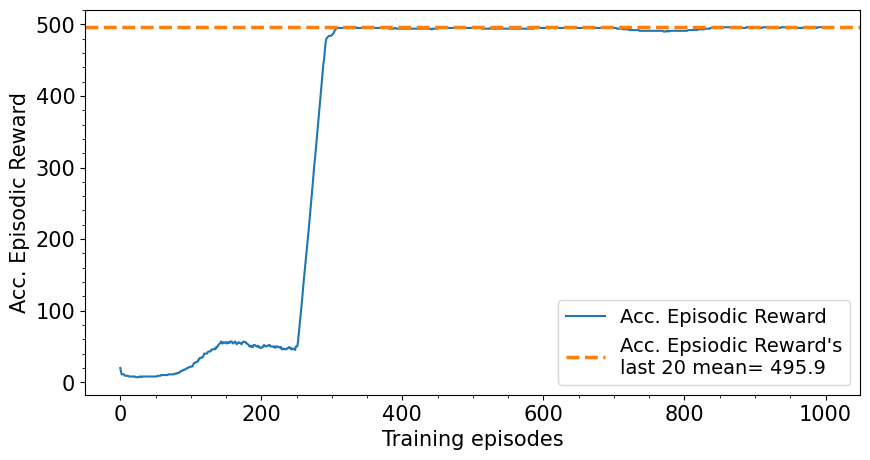

In [ ]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's\nlast 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.minorticks_on()
plt.xlabel("Training episodes")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend(fontsize=14)
plt.show()

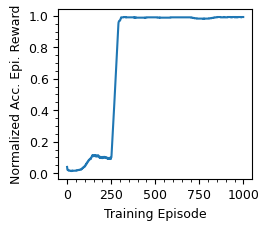

In [ ]:
# Episodes versus Avg. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
#plt.xticks(np.arange(0, 2501, 500))
#plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.minorticks_on()
#plt.savefig(path+"Cartpole_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
state = 0
action = 0
next_state = 0
next_action = 0

In [ ]:
print("Avg. Epsiodic Reward's last 5 epoch mean=")
print(np.array(avg_reward_list)[-5:].mean())

Avg. Epsiodic Reward's last 5 epoch mean=
496.0


**One Episode Test limted to 500 time steps**

In [ ]:
observation = env.reset()*0
state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
save_observation = [observation]
save_wanted_torque = [0.0]
save_actual_torque = [0.0]

done=False
t=0
while not done and t<steps_per_episode_goal:
    # using our observation, choose an action and take it in the environment
    # Get action, and take one step in the environment
    state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    action = select_action(state, 0)
    #observation_new, reward, done, _, _ = env.step(action[0].numpy())
    observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action.item())
    observation = observation_new
    save_observation.append(observation)
    save_wanted_torque.append(torque_wanted)
    save_actual_torque.append(torque_actual)
    t+=1

if done:
  print("Pole fell down during test")
else:
  print("Pole NOT fell down during test")

Pole NOT fell down during test


In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


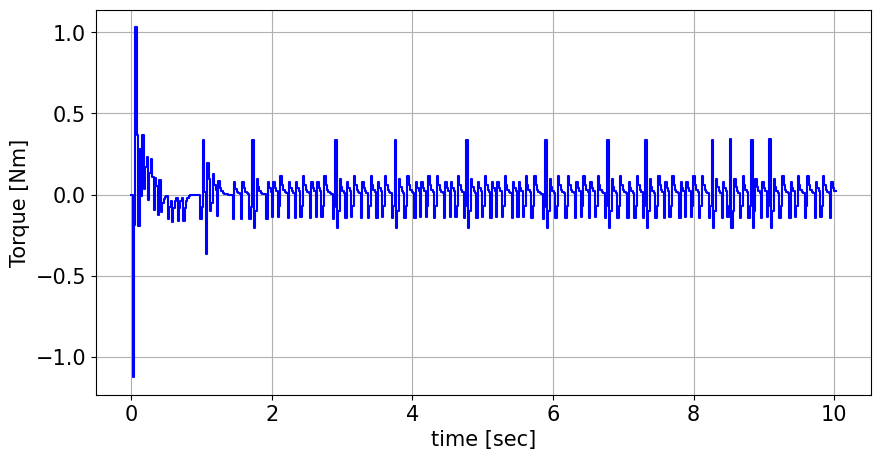

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

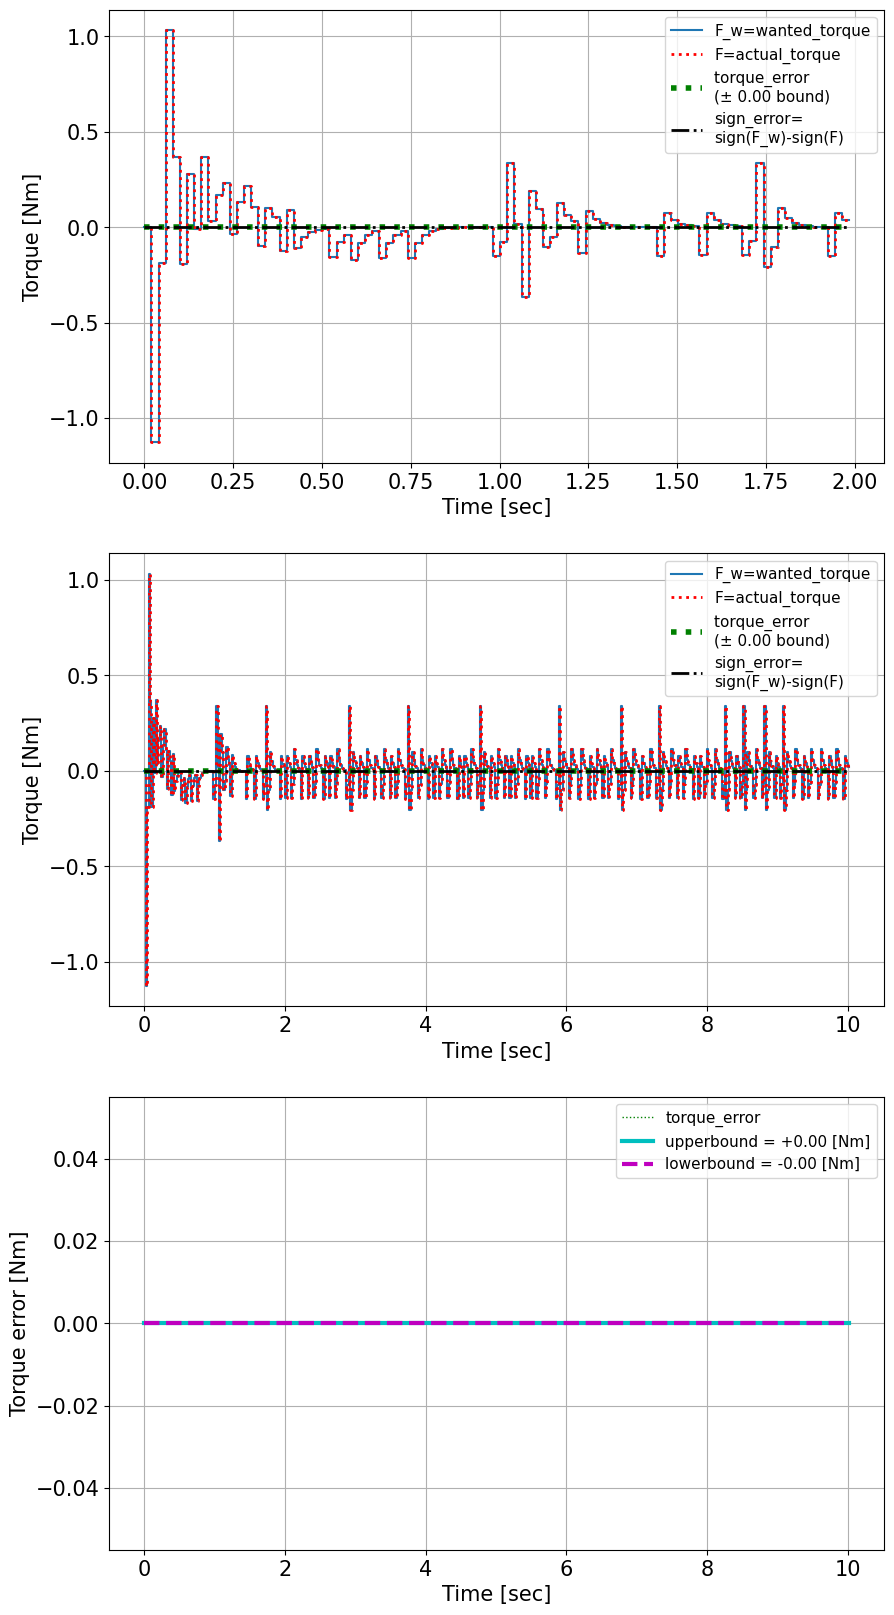

In [ ]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(20)

sign_error = np.sign(np.array(save_wanted_torque)) - np.sign(np.array(save_actual_torque))
force_error = np.array(save_wanted_torque) - np.array(save_actual_torque) ### add
force_error_max = np.max(np.abs(force_error))


plt.subplot(3, 1, 1)
plt.step(time_[:int(len(time_)/5)], save_wanted_torque[:int(len(time_)/5)],label = "F_w=wanted_torque")
plt.step(time_[:int(len(time_)/5)], save_actual_torque[:int(len(time_)/5)],':',label = "F=actual_torque",color="red",linewidth = 2)
plt.step(time_[:int(len(time_)/5)], force_error[:int(len(time_)/5)],':',
         label = f"torque_error \n(± {force_error_max:.2f} bound)",
         color="green",linewidth = 4) ### add
plt.step(time_[:int(len(time_)/5)], sign_error[:int(len(time_)/5)],'-.',label = "sign_error=\nsign(F_w)-sign(F)",color="black",linewidth = 2)
plt.legend(fontsize = 11)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Torque [Nm]')

plt.subplot(3, 1, 2)
plt.step(time_, save_wanted_torque,label = "F_w=wanted_torque")
plt.step(time_, save_actual_torque,':',label = "F=actual_torque",color="red",linewidth = 2)
plt.step(time_, force_error,':',
         label = f"torque_error \n(± {force_error_max:.2f} bound)",
         color="green",linewidth = 4) ### add
plt.step(time_, sign_error,'-.',label = "sign_error=\nsign(F_w)-sign(F)",color="black",linewidth = 2)
plt.legend(fontsize = 11)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Torque [Nm]')

plt.subplot(3, 1, 3)
plt.step(time_, force_error,':',
         label = "torque_error",
         color="green",linewidth = 1) ### add
plt.step(time_, force_error*0+force_error_max,'-',
         label = f"upperbound = +{force_error_max:.2f} [Nm]",
         color="c",linewidth = 3) ### add
plt.step(time_, force_error*0-force_error_max,'--',
         label = f"lowerbound = -{force_error_max:.2f} [Nm]",
         color="m",linewidth = 3) ### add
plt.xlabel('Time [sec]')
plt.ylabel('Torque error [Nm]')
plt.legend(fontsize = 11)
plt.grid()

plt.show()

In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

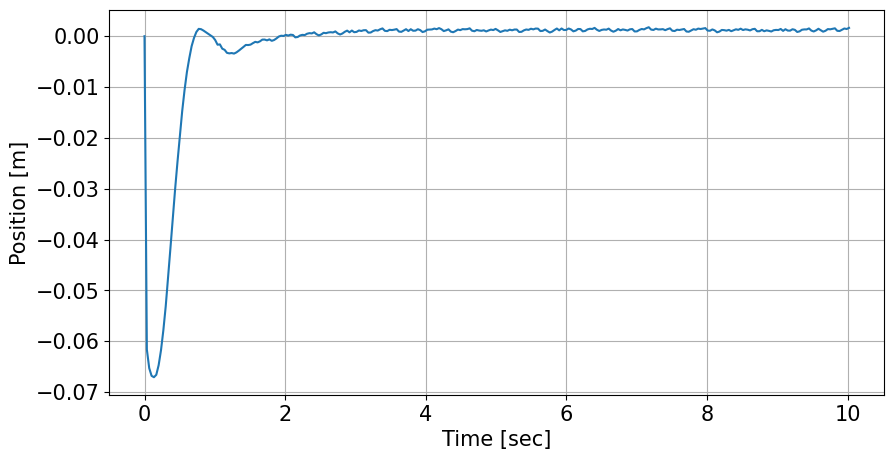

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [ ]:
print(len(position))


501


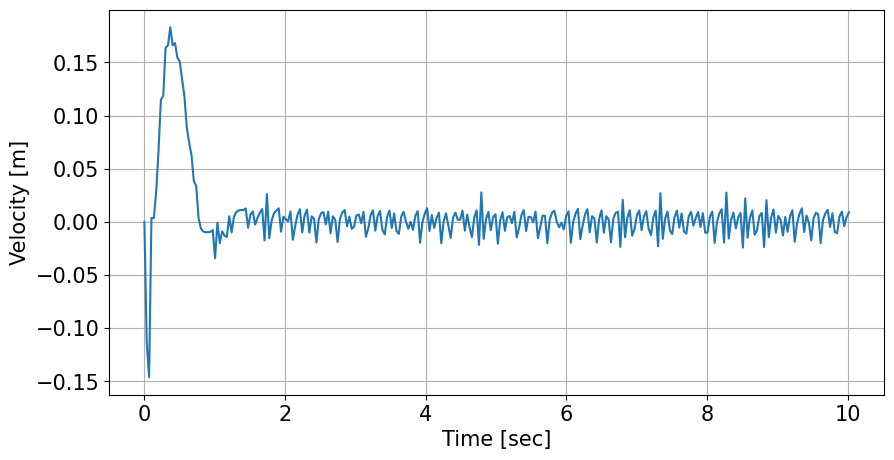

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

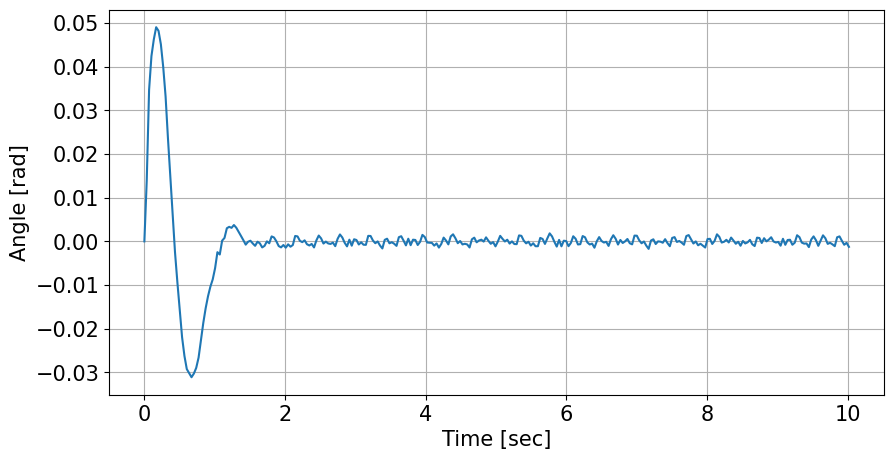

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

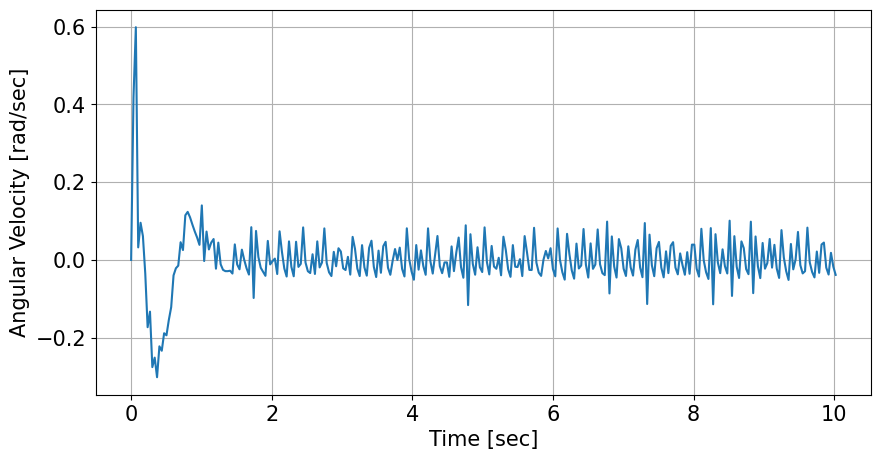

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Ideal Env**

In [ ]:
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True


In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

print('Test')
num_success = 0
for ep in range(total_episodes_test):
  observation = env.reset()
  if ep==total_episodes_test-1:
    observation*=0
    #observation[0]=1
  save_observation_temp = [observation]
  save_wanted_torque_temp = [0.0]
  save_actual_torque_temp = [0.0]
  save_sp_torque_temp = [0.0]
  save_ctrl_voltage_temp = [0.0]
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<steps_per_episode_goal:
      # using our observation, choose an action and take it in the environment
      # Get action, and take one step in the environment
      #assert state is None, "state is None before torch.tensor"
      state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
      #assert state is None, "state is None after torch.tensor"
      action = select_action(state, 0)
      #assert state is None, "action is None"
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action.item())
      observation = observation_new
      episodic_reward += reward
      episodic_abs_error_action += abs(torque_wanted-torque_actual)
      #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
      #n_count+=1
      save_observation_temp.append(observation)
      save_wanted_torque_temp.append(torque_wanted)
      save_actual_torque_temp.append(torque_actual)
      save_sp_torque_temp.append(env.MPC.y_spf)
      save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
      save_ctrl_voltage_temp.append(0.0)
      t+=1


  ep_reward_list_test.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list_test[-40:])

  ep_abs_error_action_list_test.append(episodic_abs_error_action/t)

  print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Ep. Action MAE: {(episodic_abs_error_action/t):.2e}; Pole fell: {done}")
  if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward

  #if done:
  #  print("Pole fell down during episode")
  #else:
  #  print("Pole NOT fell down during episode")
  num_success+= 0 + (not done)

Test
Episode: 0; Acc. Reward: 493.6; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 1; Acc. Reward: 495.2; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 2; Acc. Reward: 498.3; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 3; Acc. Reward: 489.1; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 4; Acc. Reward: 490.8; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 5; Acc. Reward: 492.0; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 6; Acc. Reward: 489.6; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 7; Acc. Reward: 494.4; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 8; Acc. Reward: 486.2; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 9; Acc. Reward: 493.5; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 10; Acc. Reward: 496.8; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 11; Acc. Reward: 491.9; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 12; Acc. Reward: 492.2; Ep. Action MAE: 0.00e+00; Pole fell: False
Episode: 13; Acc.

In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
493.0946157859983
Normalized mean= 9.862e-01
Normalized std = 5.535e-03


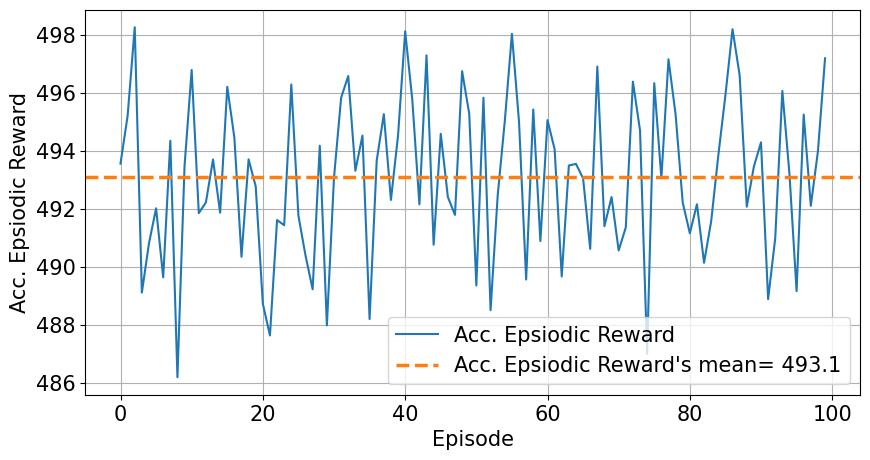

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


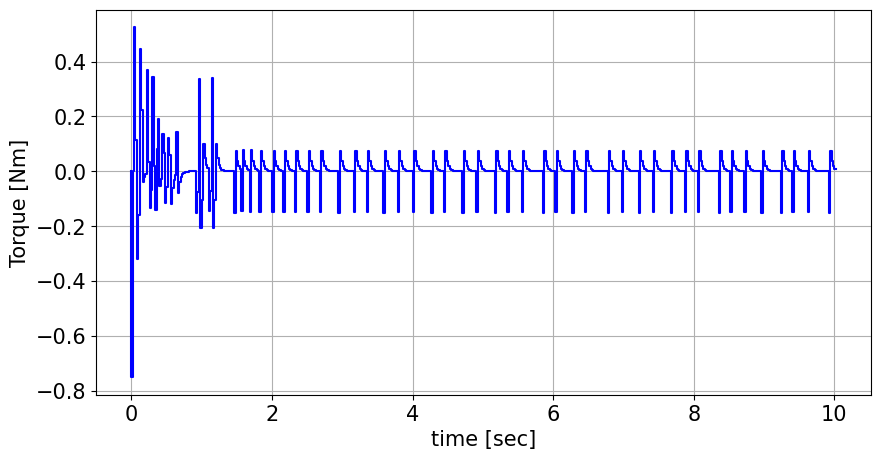

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

In [ ]:
print(len(position))

501


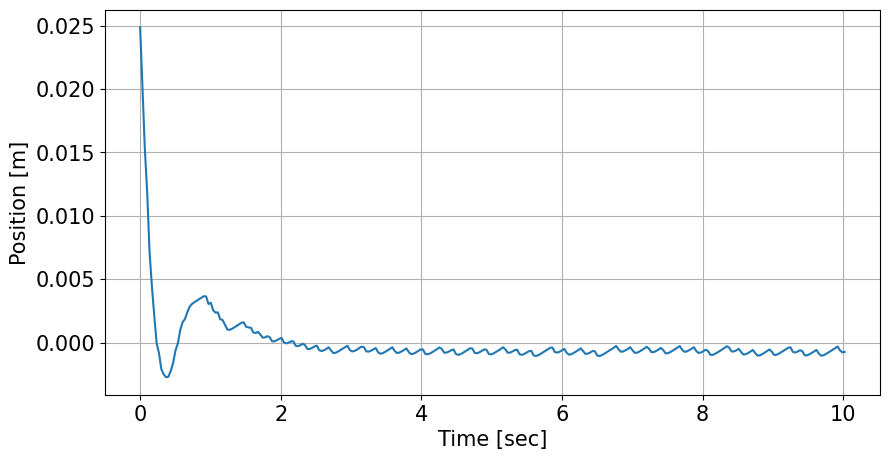

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

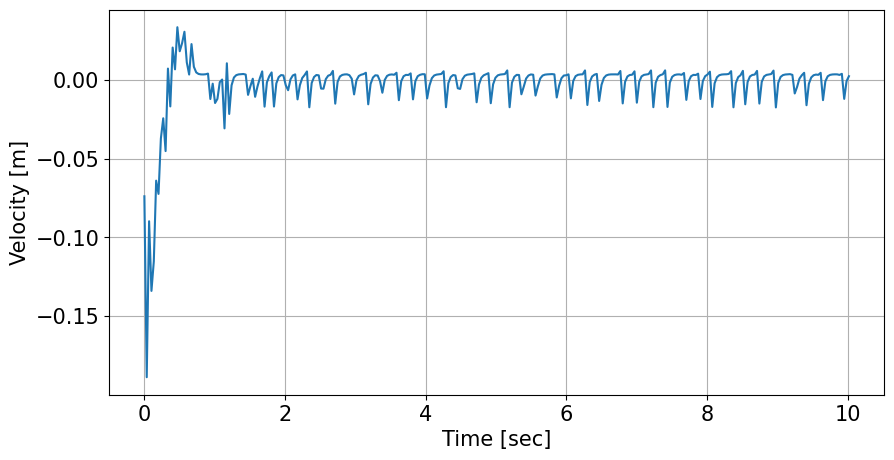

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

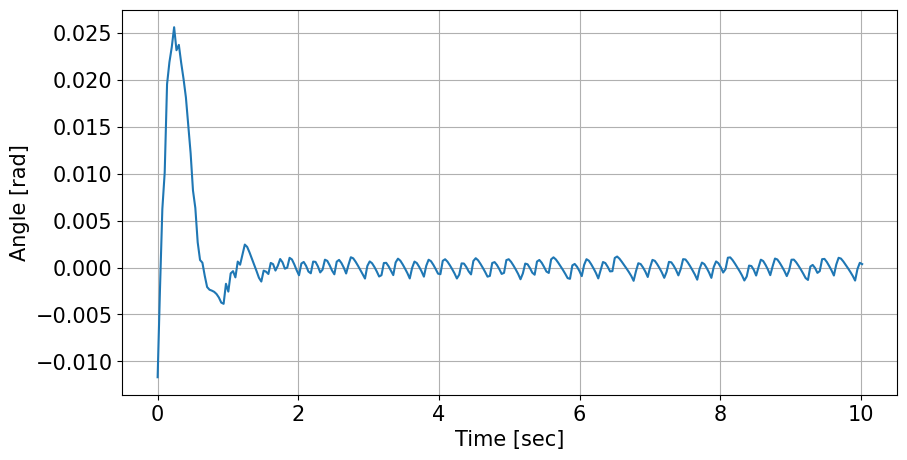

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

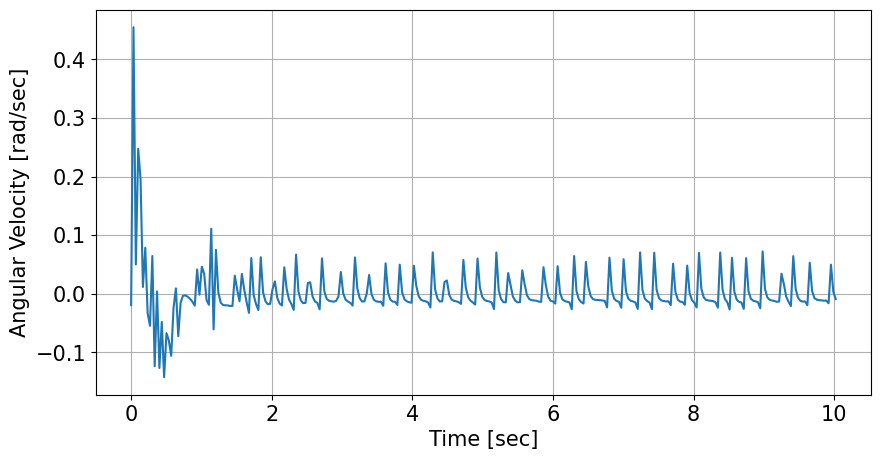

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env Ctrl**

In [ ]:
env = CartPole()
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True


## for training with desined MPC ctrl:
env.ideal_env = False

In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []


print('Test')
num_success = 0
for ep in range(total_episodes_test):
  observation = env.reset()
  if ep==total_episodes_test-1:
    observation*=0
    #observation[0]=1
  save_observation_temp = [observation]
  save_wanted_torque_temp = [0.0]
  save_actual_torque_temp = [0.0]
  save_sp_torque_temp = [0.0]
  save_ctrl_voltage_temp = [0.0]
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<steps_per_episode_goal:
      # using our observation, choose an action and take it in the environment
      # Get action, and take one step in the environment
      #assert state is None, "state is None before torch.tensor"
      state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
      #assert state is None, "state is None after torch.tensor"
      action = select_action(state, 0)
      #assert state is None, "action is None"
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action.item())
      observation = observation_new
      episodic_reward += reward
      episodic_abs_error_action += abs(torque_wanted-torque_actual)
      #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
      #n_count+=1
      save_observation_temp.append(observation)
      save_wanted_torque_temp.append(torque_wanted)
      save_actual_torque_temp.append(torque_actual)
      save_sp_torque_temp.append(env.MPC.y_spf)
      save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
      save_ctrl_voltage_temp.append(0.0)
      t+=1


  ep_reward_list_test.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list_test[-40:])

  ep_abs_error_action_list_test.append(episodic_abs_error_action/t)

  print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Ep. Action MAE: {(episodic_abs_error_action/t):.2e}; Pole fell: {done}")
  if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward

  #if done:
  #  print("Pole fell down during episode")
  #else:
  #  print("Pole NOT fell down during episode")
  num_success+= 0 + (not done)

Test
Episode: 0; Acc. Reward: 495.9; Ep. Action MAE: 2.30e-03; Pole fell: False
Episode: 1; Acc. Reward: 489.6; Ep. Action MAE: 2.26e-03; Pole fell: False
Episode: 2; Acc. Reward: 489.5; Ep. Action MAE: 2.08e-03; Pole fell: False
Episode: 3; Acc. Reward: 494.5; Ep. Action MAE: 2.16e-03; Pole fell: False
Episode: 4; Acc. Reward: 495.5; Ep. Action MAE: 2.19e-03; Pole fell: False
Episode: 5; Acc. Reward: 494.5; Ep. Action MAE: 1.81e-03; Pole fell: False
Episode: 6; Acc. Reward: 490.3; Ep. Action MAE: 2.58e-03; Pole fell: False
Episode: 7; Acc. Reward: 495.1; Ep. Action MAE: 1.43e-03; Pole fell: False
Episode: 8; Acc. Reward: 496.6; Ep. Action MAE: 1.82e-03; Pole fell: False
Episode: 9; Acc. Reward: 493.1; Ep. Action MAE: 1.96e-03; Pole fell: False
Episode: 10; Acc. Reward: 496.8; Ep. Action MAE: 2.85e-03; Pole fell: False
Episode: 11; Acc. Reward: 494.2; Ep. Action MAE: 3.15e-03; Pole fell: False
Episode: 12; Acc. Reward: 490.3; Ep. Action MAE: 3.06e-03; Pole fell: False
Episode: 13; Acc.

In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
494.0394905040136
Normalized mean= 9.881e-01
Normalized std = 5.685e-03


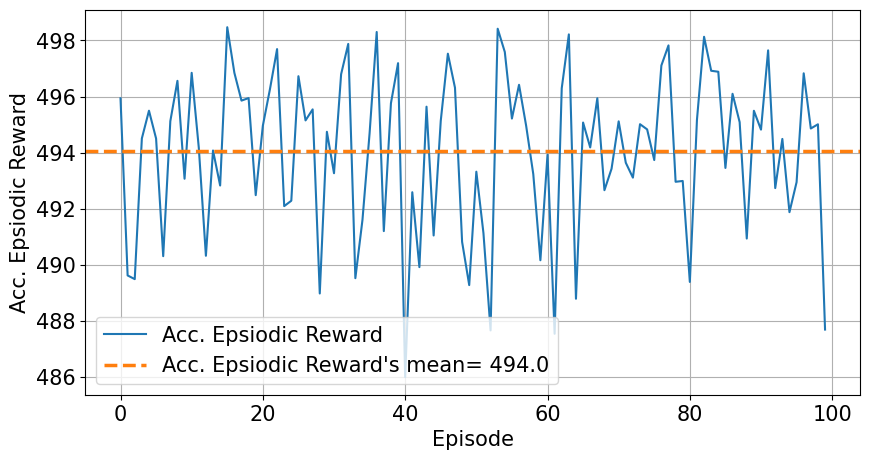

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


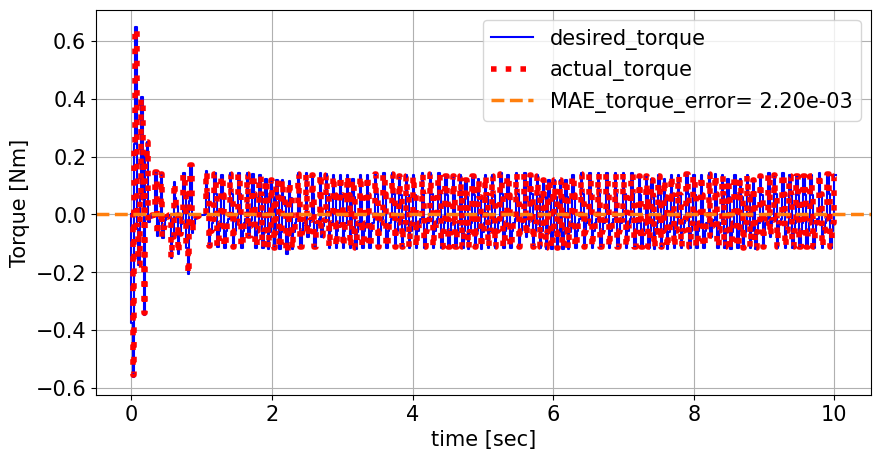

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.04,n≥2:
mean= 6.0597e-06
std= 1.9924e-03
rms= 1.9924e-03
mae= 1.4572e-03


In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

In [ ]:
print(len(position))

501


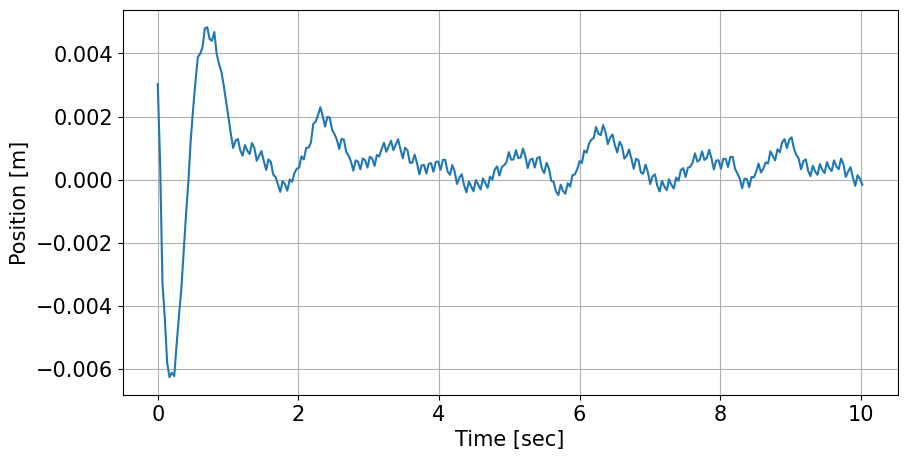

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

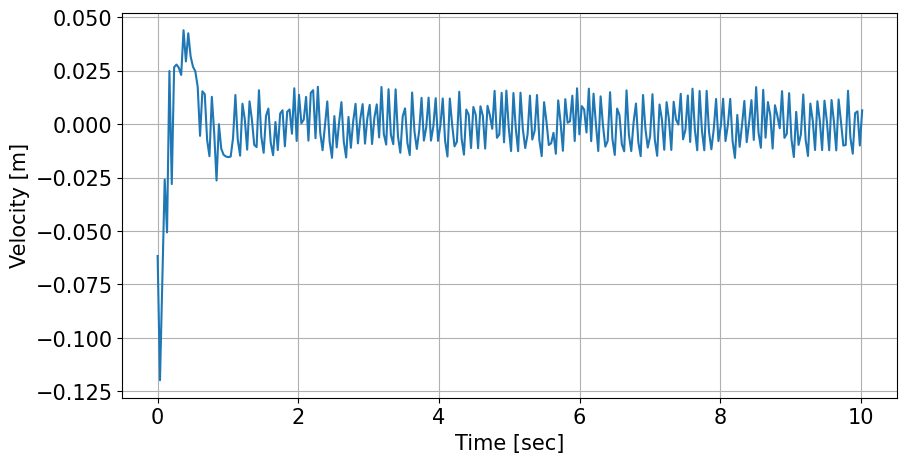

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

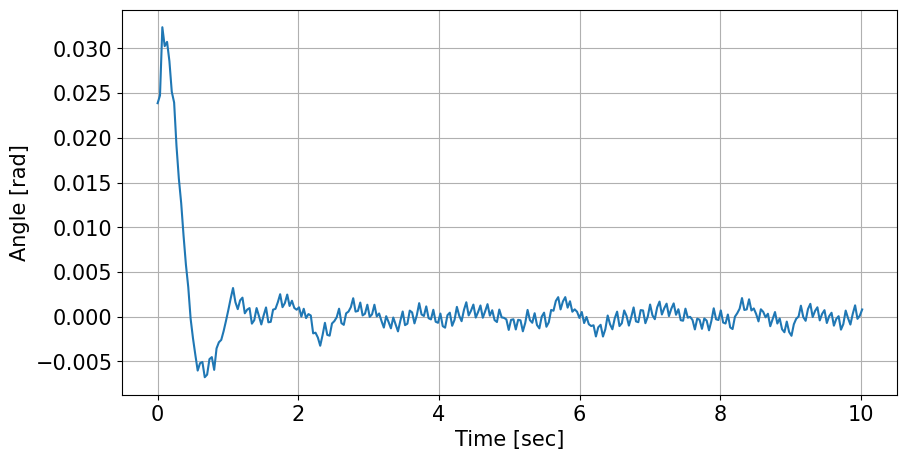

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

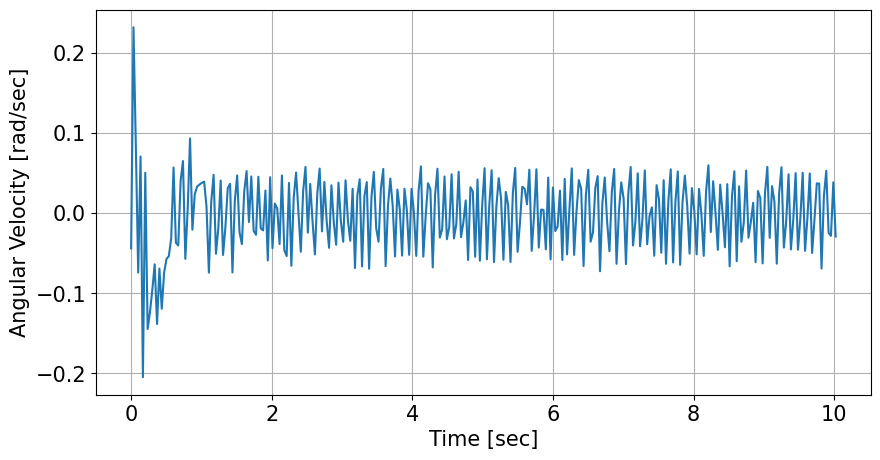

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env FF**

In [ ]:
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
env.ideal_env = False
#env.MPC.K_MPC=  np.array([[ 5.4295893,  -4.44155325]])
env.MPC.K_MPC = np.array([[ 1.0,  0.0]])
env.MPC.k_w = 0.0



In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []


print('Test')
num_success = 0
for ep in range(total_episodes_test):
  observation = env.reset()
  if ep==total_episodes_test-1:
    observation*=0
    #observation[0]=1
  save_observation_temp = [observation]
  save_wanted_torque_temp = [0.0]
  save_actual_torque_temp = [0.0]
  save_sp_torque_temp = [0.0]
  save_ctrl_voltage_temp = [0.0]
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<steps_per_episode_goal:
      # using our observation, choose an action and take it in the environment
      # Get action, and take one step in the environment
      #assert state is None, "state is None before torch.tensor"
      state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
      #assert state is None, "state is None after torch.tensor"
      action = select_action(state, 0)
      #assert state is None, "action is None"
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action.item())
      observation = observation_new
      episodic_reward += reward
      episodic_abs_error_action += abs(torque_wanted-torque_actual)
      #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
      #n_count+=1
      save_observation_temp.append(observation)
      save_wanted_torque_temp.append(torque_wanted)
      save_actual_torque_temp.append(torque_actual)
      save_sp_torque_temp.append(env.MPC.y_spf)
      save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
      save_ctrl_voltage_temp.append(0.0)
      t+=1


  ep_reward_list_test.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list_test[-40:])

  ep_abs_error_action_list_test.append(episodic_abs_error_action/t)

  print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Ep. Action MAE: {(episodic_abs_error_action/t):.2e}; Pole fell: {done}")
  if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward

  #if done:
  #  print("Pole fell down during episode")
  #else:
  #  print("Pole NOT fell down during episode")
  num_success+= 0 + (not done)

Test
Episode: 0; Acc. Reward: 59.0; Ep. Action MAE: 1.44e+00; Pole fell: True
Episode: 1; Acc. Reward: 74.8; Ep. Action MAE: 1.69e+00; Pole fell: True
Episode: 2; Acc. Reward: 55.8; Ep. Action MAE: 1.65e+00; Pole fell: True
Episode: 3; Acc. Reward: 124.4; Ep. Action MAE: 1.58e+00; Pole fell: True
Episode: 4; Acc. Reward: 97.6; Ep. Action MAE: 1.50e+00; Pole fell: True
Episode: 5; Acc. Reward: 82.3; Ep. Action MAE: 1.41e+00; Pole fell: True
Episode: 6; Acc. Reward: 69.7; Ep. Action MAE: 1.59e+00; Pole fell: True
Episode: 7; Acc. Reward: 69.6; Ep. Action MAE: 1.98e+00; Pole fell: True
Episode: 8; Acc. Reward: 175.1; Ep. Action MAE: 1.23e+00; Pole fell: True
Episode: 9; Acc. Reward: 28.2; Ep. Action MAE: 1.81e+00; Pole fell: True
Episode: 10; Acc. Reward: 65.3; Ep. Action MAE: 1.80e+00; Pole fell: True
Episode: 11; Acc. Reward: 73.9; Ep. Action MAE: 1.62e+00; Pole fell: True
Episode: 12; Acc. Reward: 99.6; Ep. Action MAE: 1.60e+00; Pole fell: True
Episode: 13; Acc. Reward: 38.9; Ep. Actio

In [ ]:
env.MPC.K_MPC=K_MPC
env.MPC.k_w = 1.0

In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(0 successes)/(100 episodes)*100=0.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
78.03141635064472
Normalized mean= 1.561e-01
Normalized std = 6.147e-02


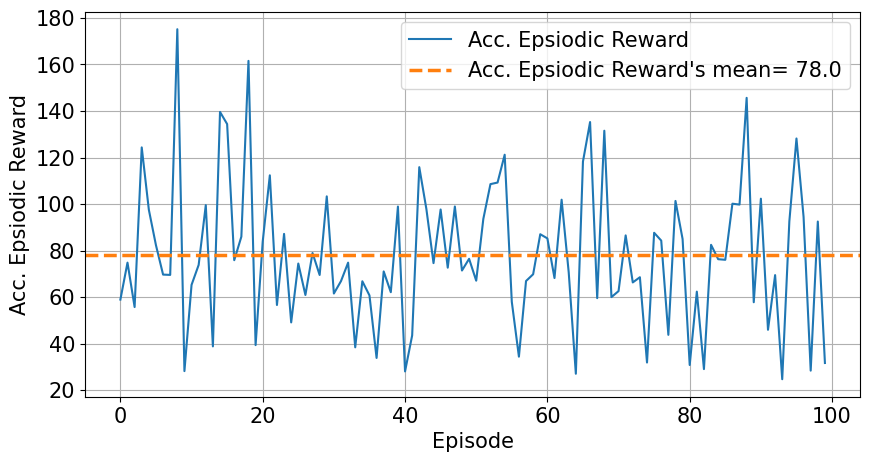

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Acc. Epsiodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())

Acc. Epsiodic Reward's mean=
78.03141635064472


In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


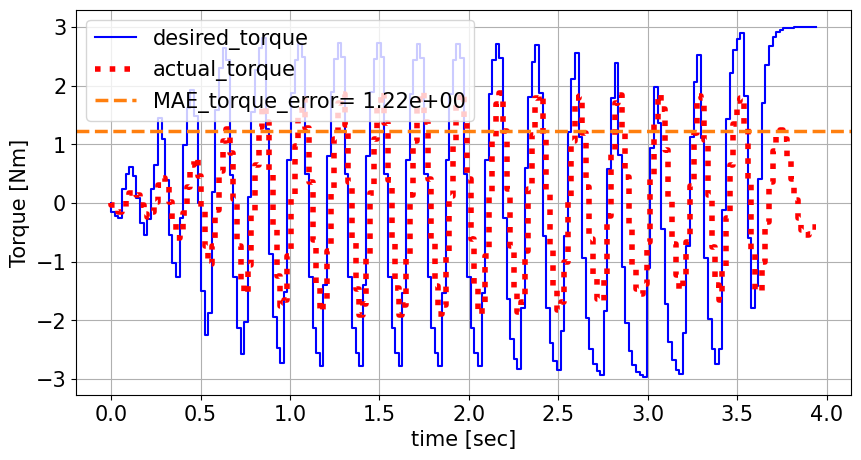

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.04,n≥2:
mean= 7.7278e-02
std= 1.4218e+00
rms= 1.4239e+00
mae= 1.2342e+00


In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

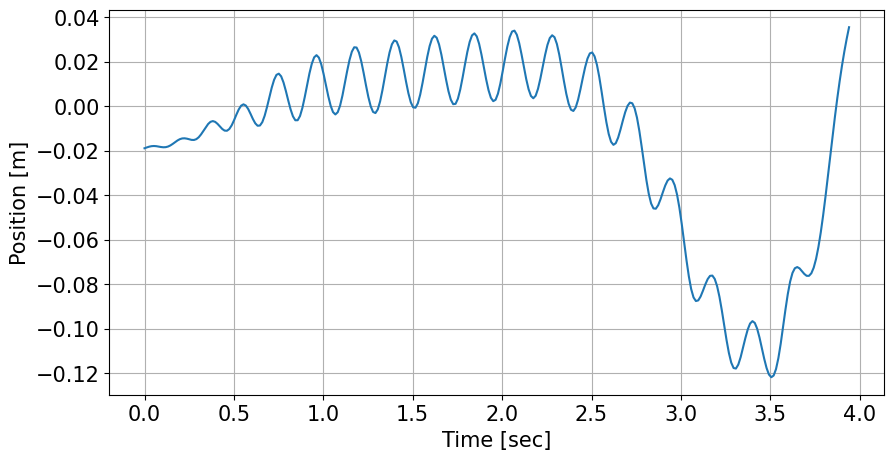

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [ ]:
print(len(position))


197


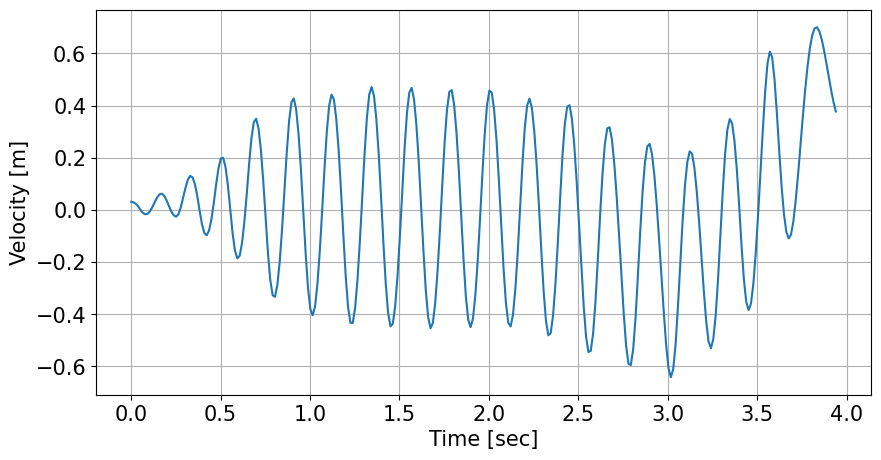

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

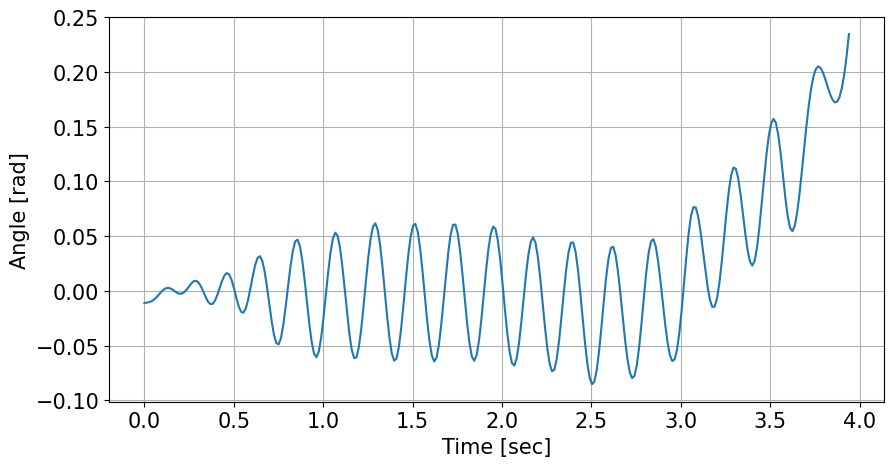

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

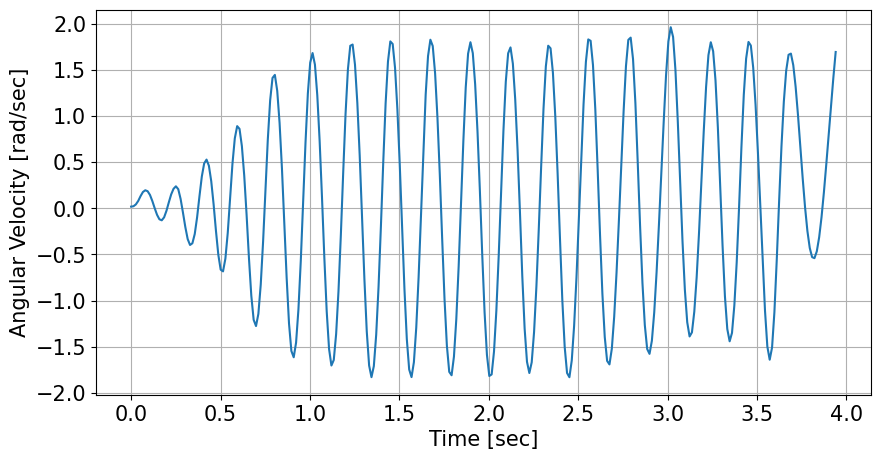

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()